# Trails temporal LCI depth sweep

This notebook runs temporal LCA for selected foreground LCI case studies using the original Trails datapackage, including all foreground and background temporal distributions.

For each selected activity it calculates depths 1 through 5, then builds one plot from the depth-5 root-attributed annual areas and overlays the five cumulative curves, one per depth.

## Modeling Convention

The foreground Excel inventories are imported as written. The notebook does not normalize inventory amounts or remove temporal distributions from the background datapackage.

Use the configuration cell to select cases, indicators, routing cutoff, reference year, and output location.
The default configuration requests the full case-study systems via case-specific functional-unit demand amounts. For example, the polyol case requests `50_000_000_000 kg` and the DACCS case requests `20_000_000_000 kg`, matching their updated production exchanges.


In [9]:
from __future__ import annotations

import csv
import gc
import importlib
import json
import importlib.util
import os
import shutil
import sys
import time
import zipfile
from dataclasses import dataclass
from pathlib import Path
from textwrap import shorten, wrap
from typing import Any

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import HTML, Image, display

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "dev":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) in sys.path:
    sys.path.remove(str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT))

# A running Jupyter kernel keeps imported modules alive. Reload Trails so
# notebook reruns pick up local source edits without requiring a kernel restart.
for _module_name in (
    "trails.characterization",
    "trails.importer",
    "trails.trails",
    "trails.lca",
    "trails.fair_rf",
    "trails.plotting",
    "trails",
):
    if _module_name in sys.modules:
        importlib.reload(sys.modules[_module_name])

RUNNER_PATH = REPO_ROOT / "dev" / "plot_terminal_lci_td_comparison.py"
spec = importlib.util.spec_from_file_location("plot_terminal_lci_td_comparison", RUNNER_PATH)
if spec is None or spec.loader is None:
    raise RuntimeError(f"Could not load runner script: {RUNNER_PATH}")
runner = importlib.util.module_from_spec(spec)
sys.modules[str(spec.name)] = runner
spec.loader.exec_module(runner)
helpers = runner.helpers
from trails.fair_rf import run_fair_co2_pulse_equivalents, run_fair_delta_rf

_lca_module = importlib.import_module("trails.lca")
print(
    "Multi-method temporal scoring active:",
    hasattr(runner.Trails, "accumulate_temporalized_biosphere_score_matrix_multi")
    and "accumulate_temporalized_biosphere_score_matrix_multi" in _lca_module.lca.__code__.co_names,
)


Multi-method temporal scoring active: True


## Configuration

In [15]:
RUN_ANALYSIS = True
RUN_REGULAR_ASSESSMENT = True  # Set False to skip regular LCIA plots and keep only FaIR runs.

# Choose any subset of: "bev", "polyol", "marine", "daccs".
# CASE_KEYS = ["bev"]
CASE_KEYS = [
    "bev",
    "polyol",
    "marine",
    "daccs"
]

METHOD_MODE = "custom"  # "custom", "ef31_headline", or "ipcc2021_incl_biogenic"
CUSTOM_METHODS = [
    #"IPCC 2021 (incl. biogenic CO2) - climate change: total (incl. biogenic CO2) - global warming potential (GWP100)",
    #'EF v3.1 - acidification - accumulated exceedance (AE)',
    #'EF v3.1 - climate change - global warming potential (GWP100)',
    #'EF v3.1 - climate change: biogenic - global warming potential (GWP100)',
    #'EF v3.1 - climate change: fossil - global warming potential (GWP100)',
    #'EF v3.1 - climate change: land use and land use change - global warming potential (GWP100)',
    #'EF v3.1 - ecotoxicity: freshwater - comparative toxic unit for ecosystems (CTUe)',
    #'EF v3.1 - ecotoxicity: freshwater, inorganics - comparative toxic unit for ecosystems (CTUe)',
    #'EF v3.1 - ecotoxicity: freshwater, organics - comparative toxic unit for ecosystems (CTUe)',
    #'EF v3.1 - energy resources: non-renewable - abiotic depletion potential (ADP): fossil fuels',
    #'EF v3.1 - eutrophication: freshwater - fraction of nutrients reaching freshwater end compartment (P)',
    #'EF v3.1 - eutrophication: marine - fraction of nutrients reaching marine end compartment (N)',
    'EF v3.1 - eutrophication: terrestrial - accumulated exceedance (AE)',
    'EF v3.1 - human toxicity: carcinogenic - comparative toxic unit for human (CTUh)',
    #'EF v3.1 - human toxicity: carcinogenic, inorganics - comparative toxic unit for human (CTUh)',
    #'EF v3.1 - human toxicity: carcinogenic, organics - comparative toxic unit for human (CTUh)',
    #'EF v3.1 - human toxicity: non-carcinogenic - comparative toxic unit for human (CTUh)',
    #'EF v3.1 - human toxicity: non-carcinogenic, inorganics - comparative toxic unit for human (CTUh)',
    #'EF v3.1 - human toxicity: non-carcinogenic, organics - comparative toxic unit for human (CTUh)',
    #'EF v3.1 - ionising radiation: human health - human exposure efficiency relative to u235',
    #'EF v3.1 - land use - soil quality index',
    'EF v3.1 - material resources: metals/minerals - abiotic depletion potential (ADP): elements (ultimate reserves)',
    #'EF v3.1 - ozone depletion - ozone depletion potential (ODP)',
    'EF v3.1 - particulate matter formation - impact on human health',
    #'EF v3.1 - photochemical oxidant formation: human health - tropospheric ozone concentration increase',
    #'EF v3.1 - water use - user deprivation potential (deprivation-weighted water consumption)',
]

DEPTHS = [
    1,
    #2,
    #3,
    #4,
    5
]
PLOT_DEPTH = 5
ACTIVITY_ATTRIBUTION_DEPTHS = [1, 5]
REFERENCE_YEAR = 2025
PLOT_WINDOW_YEARS_BEFORE = 40
PLOT_WINDOW_YEARS_AFTER = 60
PLOT_WINDOW_START_SHIFT_YEARS = 1

DATAPACKAGE = Path("/Users/romain/GitHub/premise/dev/trails_2026-05-31.zip")
LCIA_JSON = Path("/Users/romain/GitHub/pathways/pathways/data/lcia_ei312.json")
INVENTORY_PATHS = list(runner.DEFAULT_ONEDRIVE_INVENTORY_PATHS)

OUTPUT_DIR = REPO_ROOT / "dev" / "notebook_runs" / "temporal_lci_depth_sweep_runner"
LOCAL_INVENTORY_CACHE_DIR = OUTPUT_DIR / "inventory_cache"
USE_LOCAL_INVENTORY_CACHE = False

RESULTS_CSV = OUTPUT_DIR / "scores_by_depth.csv"

DEPTH_DELTA_EXPLANATION_CSV = OUTPUT_DIR / "depth_delta_explanations.csv"
RUN_DEPTH_DELTA_EXPLANATION = True
DEPTH_DELTA_EXPLANATION_BASE_DEPTH = 1
DEPTH_DELTA_EXPLANATION_COMPARE_DEPTH = 5
DEPTH_DELTA_EXPLANATION_TOP_N = 12
DEPTH_DELTA_EXPLANATION_METHODS_BY_KEY = {
    "polyol": "EF v3.1 - eutrophication: terrestrial - accumulated exceedance (AE)",
    "bev": "EF v3.1 - human toxicity: carcinogenic - comparative toxic unit for human (CTUh)",
    "marine": "EF v3.1 - material resources: metals/minerals - abiotic depletion potential (ADP): elements (ultimate reserves)",
    "daccs": "EF v3.1 - particulate matter formation - impact on human health",
}

RUN_GWP_CUMULATIVE_SUMMARY = True
GWP_CUMULATIVE_METHOD = (
    "IPCC 2021 (incl. biogenic CO2) - climate change: total "
    "(incl. biogenic CO2) - global warming potential (GWP100)"
)
GWP_CUMULATIVE_DEPTHS = [1, 5]

AMOUNT = None  # None uses CASE_DEMAND_AMOUNTS_BY_KEY; set a number to override all cases.
DEFAULT_AMOUNT = 1.0
USE_CASE_DEMAND_AMOUNTS = True
CASE_DEMAND_AMOUNTS_BY_KEY = {
    "bev": 150_000.0,
    "polyol": 50_000_000_000.0,
    "marine": 180_000_000_000.0,
    "daccs": 20_000_000_000.0,
}

CASE_ACTIVITY_DEFS_BY_KEY = dict(runner.DEFAULT_CASE_STUDY_ACTIVITY_KEYS)
CASE_ACTIVITY_DEFS_BY_KEY["polyol"] = helpers.ActivityDef(
    "polyol precursor production from captured CO2",
    "polyol precursor",
    "RER",
)
EI_VERSION = "3.12"
SOLVER_MODE = "iterative"
FALLBACK_SOLVER_MODE = "direct"  # use "none" to fail instead of falling back
ITERATIVE_RTOL = 1e-3
ITERATIVE_ATOL = 0.0
ITERATIVE_RESTART = 100
ITERATIVE_MAXITER = 1000
ITERATIVE_USE_GUESS = True
ITERATIVE_PRECONDITIONER = "jacobi"  # "jacobi", "ilu", or "none"
ITERATIVE_ILU_DROP_TOL = 1e-4
ITERATIVE_ILU_FILL_FACTOR = 10.0
ROUTING_MIN_AMOUNT = 1e-3
SHOW_PROGRESS = False
PROFILE_LCA_INTERNALS = True
NO_CACHE_INTERPOLATION = False
INTERPOLATION_START_YEAR_OFFSET = -20
INTERPOLATION_END_YEAR_OFFSET = 20
IMPORT_BEFORE_INTERPOLATION = False

# Keep this False so the routing cutoff remains absolute, not case-size scaled.
SCALE_ROUTING_MIN_AMOUNT_BY_ACTIVITY = False

WIDTH = 640
HEIGHT = 504
LEGEND_ENTRY_WIDTH = 245
LEGEND_ENTRY_WIDTH_MODE = "pixels"
LEGEND_LABEL_MAX_CHARS = 35
LEGEND_COLUMNS = 2
LEGEND_MAX_ROWS = 5
X_TICK_YEARS = 10
WRITE_HTML = False
WRITE_PNG = True  # requires kaleido
PNG_SCALE = 3  # high-definition export multiplier for Plotly PNG output
STACKED_AREA_MODES = [False, True]  # False = overlaid areas; True = stacked areas.
DISPLAY_FIRST_FIGURE = True

# Optional FaIR climate-response pass. The FaIR run uses the raw,
# root-attributed inventory saved by trails.lca(store_inventory=True).
RUN_FAIR = True
FAIR_DEPTHS = [1, 5]
FAIR_PLOT_DEPTH = 5
FAIR_COMPARE_DEPTH = 1
FAIR_SCENARIO = "REMIND|SSP2-PkBudg650"
FAIR_CONFIG_NAME = None
FAIR_CONFIG_NAMES = None
FAIR_QUANTILES = [50.0]
FAIR_QUANTILE = 50.0
FAIR_PER_SPECIES_RUNS = False
FAIR_PER_SPECIES_WORKERS = None
FAIR_VALIDATE_EMISSIONS_DELTA = True
FAIR_VALIDATE_RAISE = False
FAIR_SCALE_FACTOR = None
FAIR_SCALE_TARGET_FRACTION = 0.01
FAIR_EXCLUDE_AEROSOL_OZONE_PRECURSORS = True
RUN_CO2_PULSE_EQUIVALENTS = True
CO2_PULSE_EQUIVALENT_DEPTHS = [1, 5]
CO2_PULSE_REFERENCE_YEAR = 2025
CO2_PULSE_WINDOW_START = 2025
CO2_PULSE_WINDOW_END = 2100
CO2_PULSE_REFERENCE_MASS_KG = 1.0e9
CO2_PULSE_CO2_SPECIES_NAME = "CO2 FFI"
FAIR_YEAR_START = 1990
FAIR_YEAR_END = 2100
FAIR_STACKED_AREAS = True
FAIR_TOP_ROOT_ACTIVITIES = None  # None uses the legend capacity.
FAIR_TOTAL_LINE_WIDTH = 5.2
FAIR_COMPARE_TOTAL_LINE_WIDTH = 4.4


In [16]:
IPCC_2021_INCL_BIOGENIC = (
    "IPCC 2021 (incl. biogenic CO2) - climate change: total "
    "(incl. biogenic CO2) - global warming potential (GWP100)"
)

DEPTH_COLORS = {
    1: "#FFA500",  # orange
    2: "#D55E00",  # vermillion
    3: "#009E73",  # green
    4: "#CC79A7",  # reddish purple
    5: "#FF0000",  # bright red
}
DEPTH_CUMULATIVE_LINE_WIDTH = 4.4
DEPTH_CUMULATIVE_FOCUS_WIDTH = 5.2
DEPTH_CUMULATIVE_MUTED_OPACITY = 0.65


@dataclass
class DepthResult:
    depth: int
    scores: Any
    activity_scores: Any
    static_scores: dict[str, float]
    years_by_method: dict[str, np.ndarray]
    annual_by_method: dict[str, np.ndarray]
    cumulative_by_method: dict[str, np.ndarray]
    total_by_method: dict[str, float]


@dataclass
class FairDepthResult:
    depth: int
    amount: float
    delta_temperature: Any
    co2_pulse_equivalent: dict[str, Any] | None = None


def selected_methods() -> list[str]:
    available = runner.get_lcia_method_names(ei_version=EI_VERSION)
    if METHOD_MODE == "ef31_headline":
        methods = list(runner.EF_V31_HEADLINE_METHODS)
    elif METHOD_MODE == "ipcc2021_incl_biogenic":
        methods = [IPCC_2021_INCL_BIOGENIC]
    elif METHOD_MODE == "custom":
        methods = list(CUSTOM_METHODS)
    else:
        raise ValueError(f"Unknown METHOD_MODE: {METHOD_MODE!r}")

    missing = [method for method in methods if method not in available]
    if missing:
        raise ValueError(
            "LCIA method(s) not found for ecoinvent "
            f"{EI_VERSION}:\n- " + "\n- ".join(missing)
        )
    return list(dict.fromkeys(methods))


def selected_gwp_summary_methods() -> list[str]:
    if not bool(RUN_GWP_CUMULATIVE_SUMMARY):
        return []
    method = str(GWP_CUMULATIVE_METHOD)
    available = runner.get_lcia_method_names(ei_version=EI_VERSION)
    if method not in available:
        raise ValueError(
            "GWP_CUMULATIVE_METHOD not found for ecoinvent "
            f"{EI_VERSION}: {method}"
        )
    return [method]


def selected_depth_delta_explanation_methods() -> list[str]:
    if not bool(RUN_DEPTH_DELTA_EXPLANATION):
        return []
    available = runner.get_lcia_method_names(ei_version=EI_VERSION)
    selected = [
        str(method)
        for key, method in DEPTH_DELTA_EXPLANATION_METHODS_BY_KEY.items()
        if key in CASE_KEYS
    ]
    missing = [method for method in selected if method not in available]
    if missing:
        raise ValueError(
            "Depth-delta explanation LCIA method(s) not found for ecoinvent "
            f"{EI_VERSION}:\n- " + "\n- ".join(missing)
        )
    return list(dict.fromkeys(selected))


def selected_activities() -> list[Any]:
    return [CASE_ACTIVITY_DEFS_BY_KEY[key] for key in CASE_KEYS]


def validate_config(methods: list[str], activities: list[Any]) -> None:
    missing = [path for path in [DATAPACKAGE, *INVENTORY_PATHS] if not path.exists()]
    if (
        (bool(RUN_REGULAR_ASSESSMENT) or bool(RUN_GWP_CUMULATIVE_SUMMARY))
        and LCIA_JSON is not None
        and not LCIA_JSON.exists()
    ):
        missing.append(LCIA_JSON)
    if missing:
        raise FileNotFoundError("\n".join(str(path) for path in missing))
    if PLOT_DEPTH not in DEPTHS:
        raise ValueError("PLOT_DEPTH must be one of DEPTHS.")
    missing_activity_depths = [
        depth for depth in ACTIVITY_ATTRIBUTION_DEPTHS if depth not in DEPTHS
    ]
    if missing_activity_depths:
        raise ValueError(
            "ACTIVITY_ATTRIBUTION_DEPTHS must be included in DEPTHS: "
            f"{missing_activity_depths}"
        )
    if bool(RUN_REGULAR_ASSESSMENT) and not methods:
        raise ValueError("No LCIA methods selected.")
    if not activities:
        raise ValueError("No case-study activities selected.")

    if bool(RUN_DEPTH_DELTA_EXPLANATION):
        explanation_depths = [
            int(DEPTH_DELTA_EXPLANATION_BASE_DEPTH),
            int(DEPTH_DELTA_EXPLANATION_COMPARE_DEPTH),
        ]
        missing_explanation_depths = [
            depth for depth in explanation_depths if depth not in DEPTHS
        ]
        if missing_explanation_depths:
            raise ValueError(
                "Depth-delta explanation depths must be included in DEPTHS: "
                f"{missing_explanation_depths}"
            )
        missing_explanation_cases = [
            key
            for key in CASE_KEYS
            if key not in DEPTH_DELTA_EXPLANATION_METHODS_BY_KEY
        ]
        if missing_explanation_cases:
            raise ValueError(
                "DEPTH_DELTA_EXPLANATION_METHODS_BY_KEY has no method for: "
                f"{missing_explanation_cases}"
            )
    if bool(RUN_GWP_CUMULATIVE_SUMMARY):
        missing_gwp_depths = [
            depth for depth in GWP_CUMULATIVE_DEPTHS if int(depth) not in DEPTHS
        ]
        if missing_gwp_depths:
            raise ValueError(
                "GWP_CUMULATIVE_DEPTHS must be included in DEPTHS: "
                f"{missing_gwp_depths}"
            )
    if bool(RUN_FAIR):
        fair_depths = sorted(dict.fromkeys(int(depth) for depth in FAIR_DEPTHS))
        missing_fair_depths = [depth for depth in fair_depths if depth not in DEPTHS]
        if missing_fair_depths:
            raise ValueError(
                "FAIR_DEPTHS must be included in DEPTHS: "
                f"{missing_fair_depths}"
            )
        if int(FAIR_PLOT_DEPTH) not in fair_depths:
            raise ValueError("FAIR_PLOT_DEPTH must be included in FAIR_DEPTHS.")
        if int(FAIR_COMPARE_DEPTH) not in fair_depths:
            raise ValueError("FAIR_COMPARE_DEPTH must be included in FAIR_DEPTHS.")
        if int(FAIR_YEAR_START) >= int(FAIR_YEAR_END):
            raise ValueError("FAIR_YEAR_START must be before FAIR_YEAR_END.")
    if bool(RUN_CO2_PULSE_EQUIVALENTS):
        if not bool(RUN_FAIR):
            raise ValueError("RUN_CO2_PULSE_EQUIVALENTS requires RUN_FAIR=True.")
        missing_pulse_depths = [
            depth
            for depth in CO2_PULSE_EQUIVALENT_DEPTHS
            if int(depth) not in DEPTHS
        ]
        if missing_pulse_depths:
            raise ValueError(
                "CO2_PULSE_EQUIVALENT_DEPTHS must be included in DEPTHS: "
                f"{missing_pulse_depths}"
            )
        missing_pulse_inventory_depths = [
            depth
            for depth in CO2_PULSE_EQUIVALENT_DEPTHS
            if int(depth) not in FAIR_DEPTHS
        ]
        if missing_pulse_inventory_depths:
            raise ValueError(
                "CO2_PULSE_EQUIVALENT_DEPTHS must also be included in FAIR_DEPTHS "
                "so the inventory is stored: "
                f"{missing_pulse_inventory_depths}"
            )
        if int(CO2_PULSE_WINDOW_START) >= int(CO2_PULSE_WINDOW_END):
            raise ValueError("CO2_PULSE_WINDOW_START must be before CO2_PULSE_WINDOW_END.")


DEPTHS = sorted(dict.fromkeys(int(depth) for depth in DEPTHS))
if not DEPTHS:
    raise ValueError("DEPTHS must contain at least one depth.")
if PLOT_DEPTH not in DEPTHS:
    replacement_depth = max(DEPTHS)
    print(
        f"PLOT_DEPTH={PLOT_DEPTH} is not in DEPTHS={DEPTHS}; "
        f"using PLOT_DEPTH={replacement_depth}."
    )
    PLOT_DEPTH = replacement_depth
ACTIVITY_ATTRIBUTION_DEPTHS = [
    int(depth) for depth in ACTIVITY_ATTRIBUTION_DEPTHS if int(depth) in DEPTHS
]
if not ACTIVITY_ATTRIBUTION_DEPTHS:
    ACTIVITY_ATTRIBUTION_DEPTHS = [PLOT_DEPTH]
GWP_CUMULATIVE_DEPTHS = sorted(
    dict.fromkeys(int(depth) for depth in GWP_CUMULATIVE_DEPTHS)
)
FAIR_DEPTHS = sorted(dict.fromkeys(int(depth) for depth in FAIR_DEPTHS))
FAIR_PLOT_DEPTH = int(FAIR_PLOT_DEPTH)
FAIR_COMPARE_DEPTH = int(FAIR_COMPARE_DEPTH)
CO2_PULSE_EQUIVALENT_DEPTHS = sorted(
    dict.fromkeys(int(depth) for depth in CO2_PULSE_EQUIVALENT_DEPTHS)
)
DEPTH_DELTA_EXPLANATION_BASE_DEPTH = int(DEPTH_DELTA_EXPLANATION_BASE_DEPTH)
DEPTH_DELTA_EXPLANATION_COMPARE_DEPTH = int(DEPTH_DELTA_EXPLANATION_COMPARE_DEPTH)

regular_methods = selected_methods() if bool(RUN_REGULAR_ASSESSMENT) else []
gwp_summary_methods = selected_gwp_summary_methods()
depth_delta_explanation_methods = selected_depth_delta_explanation_methods()
lca_methods = list(
    dict.fromkeys([*regular_methods, *gwp_summary_methods, *depth_delta_explanation_methods])
)
methods = regular_methods
activities = selected_activities()
validate_config(lca_methods, activities)

print("Selected activities:")
for activity in activities:
    print(f" - {activity.name} | {activity.reference_product} | {activity.location}")
if methods:
    print("Selected regular LCIA methods:")
    for method in methods:
        print(f" - {method}")
elif lca_methods:
    print("Regular LCIA plots disabled; summary/diagnostic LCIA methods:")
    for method in lca_methods:
        print(f" - {method}")
else:
    print("Regular LCIA assessment disabled; FaIR inventory runs only.")


Selected activities:
 - transport, passenger, car, battery electric | transport, passenger, car | RER
 - polyol precursor production from captured CO2 | polyol precursor | RER
 - marine freight service, temporal fuel transition | transport service | RER
 - carbon dioxide, captured, with a solvent-based direct air capture system, 1MtCO2 | carbon dioxide, captured | Europe
Selected regular LCIA methods:
 - EF v3.1 - eutrophication: terrestrial - accumulated exceedance (AE)
 - EF v3.1 - human toxicity: carcinogenic - comparative toxic unit for human (CTUh)
 - EF v3.1 - material resources: metals/minerals - abiotic depletion potential (ADP): elements (ultimate reserves)
 - EF v3.1 - particulate matter formation - impact on human health


## Helpers

In [ ]:


def _is_readable_xlsx(path: Path) -> tuple[bool, str]:
    try:
        with path.open("rb") as handle:
            header = handle.read(4)
    except Exception as exc:
        return False, f"cannot read file bytes ({type(exc).__name__}: {exc})"
    if header != b"PK\x03\x04":
        return False, f"not an .xlsx ZIP header: {header!r}"
    try:
        if not zipfile.is_zipfile(path):
            return False, "not a valid ZIP container"
    except Exception as exc:
        return False, f"ZIP validation failed ({type(exc).__name__}: {exc})"
    return True, ""


def _stage_inventory_paths(paths: list[Path]) -> list[Path]:
    if not bool(USE_LOCAL_INVENTORY_CACHE):
        return paths

    cache_dir = Path(LOCAL_INVENTORY_CACHE_DIR)
    cache_dir.mkdir(parents=True, exist_ok=True)
    staged_paths: list[Path] = []
    failures: list[str] = []

    for source_path in paths:
        source_path = Path(source_path).expanduser().resolve()
        target_path = cache_dir / source_path.name

        source_ok, source_reason = _is_readable_xlsx(source_path)
        if source_ok:
            try:
                shutil.copy2(source_path, target_path)
            except Exception as exc:
                failures.append(
                    f"{source_path}: copy to local cache failed "
                    f"({type(exc).__name__}: {exc})"
                )
                continue
        else:
            target_ok, target_reason = _is_readable_xlsx(target_path)
            if not target_ok:
                failures.append(
                    f"{source_path}: {source_reason}. No valid cached copy at "
                    f"{target_path} ({target_reason})."
                )
                continue

        staged_paths.append(target_path)

    if failures:
        raise RuntimeError(
            "Could not stage all Excel inventories from OneDrive. "
            "Open/download these files locally, then rerun the notebook:\n- "
            + "\n- ".join(failures)
        )

    print(
        "Using local inventory cache: " + str(cache_dir),
        flush=True,
    )
    return staged_paths


def load_trails_context(methods: list[str] | None = None):
    if LCIA_JSON is not None:
        os.environ["TRAILS_LCIA_EI312_JSON"] = str(LCIA_JSON.expanduser().resolve())

    trails = runner._load_trails(
        datapackage=DATAPACKAGE.expanduser().resolve(),
        interpolation_cache_dir=None,
        inventory_paths=_stage_inventory_paths(
            [path.expanduser().resolve() for path in INVENTORY_PATHS]
        ),
        import_before_interpolation=bool(IMPORT_BEFORE_INTERPOLATION),
        remove_base_temporal_distributions=False,
        no_cache_interpolation=bool(NO_CACHE_INTERPOLATION),
        interpolation_start_year_offset=int(INTERPOLATION_START_YEAR_OFFSET),
        interpolation_end_year_offset=int(INTERPOLATION_END_YEAR_OFFSET),
    )
    trails.methods = list(methods) if methods else None
    trails.default_methods = trails.methods
    trails.ei_version = str(EI_VERSION)
    trails.default_ei_version = trails.ei_version
    return trails


def _method_label(method: str) -> str:
    if method.startswith("EF v3.1 - "):
        return method.removeprefix("EF v3.1 - ")
    return method


def _wrapped(value: str, width: int) -> str:
    lines = wrap(str(value), width=width, break_long_words=False, break_on_hyphens=False)
    return "<br>".join(lines) if lines else str(value)


_LCIA_METHOD_UNITS_BY_VERSION: dict[str, dict[str, str]] = {}


def _method_unit(method: str) -> str:
    cache_key = str(EI_VERSION)
    if cache_key not in _LCIA_METHOD_UNITS_BY_VERSION:
        from trails.lcia import _get_lcia_methods_filepath

        path = _get_lcia_methods_filepath(str(EI_VERSION))
        with path.open("r") as handle:
            data = json.load(handle)
        _LCIA_METHOD_UNITS_BY_VERSION[cache_key] = {
            " - ".join(item["name"]): str(item.get("unit") or "")
            for item in data
        }
    return _LCIA_METHOD_UNITS_BY_VERSION[cache_key].get(method, "")


def _axis_title(base: str, method: str) -> str:
    unit = _method_unit(method)
    return f"{base} ({unit})" if unit else base


def _axis_titles_for_method(method: str) -> tuple[str, str]:
    return (
        _axis_title("Annual impact", method),
        _axis_title("Cumulative / static impact", method),
    )


def _score_series(scores: Any, method: str) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    years, annual = helpers._temporal_score_by_year_from_scores(scores, method)
    annual = np.asarray(annual, dtype=float)
    cumulative = np.cumsum(annual)
    return np.asarray(years, dtype=int), annual, cumulative


def plot_year_bounds() -> tuple[int, int]:
    return (
        int(REFERENCE_YEAR)
        - int(PLOT_WINDOW_YEARS_BEFORE)
        + int(PLOT_WINDOW_START_SHIFT_YEARS),
        int(REFERENCE_YEAR) + int(PLOT_WINDOW_YEARS_AFTER),
    )


def x_tick_start(year_start: int) -> int:
    step = int(X_TICK_YEARS)
    if step <= 0:
        return int(year_start)
    return int(np.ceil(int(year_start) / step) * step)


def legend_top_n_for_plot(*, extra_legend_entries: int) -> int:
    max_entries = int(LEGEND_COLUMNS) * int(LEGEND_MAX_ROWS)
    return max(1, max_entries - int(extra_legend_entries))


def _case_key_for_activity(activity: Any) -> str | None:
    for key, candidate in CASE_ACTIVITY_DEFS_BY_KEY.items():
        if candidate == activity:
            return str(key)
    return None


def demand_amount_for_activity(activity: Any | None) -> float:
    if AMOUNT is not None:
        return float(AMOUNT)
    if bool(USE_CASE_DEMAND_AMOUNTS) and activity is not None:
        key = _case_key_for_activity(activity)
        if key is not None and key in CASE_DEMAND_AMOUNTS_BY_KEY:
            return float(CASE_DEMAND_AMOUNTS_BY_KEY[key])
    return float(DEFAULT_AMOUNT)


def _scores_reduced_to_method_activity_year(scores: Any):
    if "activity" not in scores.dims:
        raise RuntimeError(
            "Cannot build by-activity plot: score tensor has no activity "
            "dimension."
        )
    keep_dims = [
        dim for dim in ("method", "activity", "year") if dim in scores.dims
    ]
    reduce_dims = [dim for dim in scores.dims if dim not in keep_dims]
    data = scores
    if reduce_dims:
        data = data.sum(dim=reduce_dims)
    if data.dims != tuple(keep_dims):
        data = data.transpose(*keep_dims)
    return data


def _depth_result_from_scores(
    *,
    depth: int,
    scores: Any,
    activity_scores: Any,
    static_scores: dict[str, float],
    methods: list[str],
) -> DepthResult:
    years_by_method = {}
    annual_by_method = {}
    cumulative_by_method = {}
    total_by_method = {}
    for method in methods:
        years, annual, cumulative = _score_series(scores, method)
        years_by_method[method] = years
        annual_by_method[method] = annual
        cumulative_by_method[method] = cumulative
        total_by_method[method] = float(cumulative[-1]) if cumulative.size else 0.0
    return DepthResult(
        depth=int(depth),
        scores=scores,
        activity_scores=activity_scores,
        static_scores=dict(static_scores),
        years_by_method=years_by_method,
        annual_by_method=annual_by_method,
        cumulative_by_method=cumulative_by_method,
        total_by_method=total_by_method,
    )



def _timed_lca_call(
    trails: Any,
    *,
    methods: list[str],
    store_inventory: bool = False,
    compute_score: bool = True,
) -> None:
    stats: dict[str, dict[str, float]] = {}
    wrapped: list[tuple[Any, str, Any]] = []

    def wrap(obj: Any, name: str) -> None:
        if not hasattr(obj, name):
            return
        original = getattr(obj, name)

        def timed(*args: Any, **kwargs: Any) -> Any:
            start = time.perf_counter()
            try:
                return original(*args, **kwargs)
            finally:
                bucket = stats.setdefault(name, {"calls": 0.0, "seconds": 0.0})
                bucket["calls"] += 1.0
                bucket["seconds"] += time.perf_counter() - start

        setattr(obj, name, timed)
        wrapped.append((obj, name, original))

    def run_with_solver(solver_mode: str) -> None:
        trails.lca(
            show_progress=bool(SHOW_PROGRESS),
            attribute_to_roots=True,
            compute_score=bool(compute_score),
            store_inventory=bool(store_inventory),
            solver_mode=str(solver_mode),
            iterative_rtol=float(ITERATIVE_RTOL),
            iterative_atol=float(ITERATIVE_ATOL),
            iterative_restart=None if ITERATIVE_RESTART is None else int(ITERATIVE_RESTART),
            iterative_maxiter=None if ITERATIVE_MAXITER is None else int(ITERATIVE_MAXITER),
            iterative_use_guess=bool(ITERATIVE_USE_GUESS),
            iterative_preconditioner=str(ITERATIVE_PRECONDITIONER),
            iterative_ilu_drop_tol=float(ITERATIVE_ILU_DROP_TOL),
            iterative_ilu_fill_factor=float(ITERATIVE_ILU_FILL_FACTOR),
        )

    if bool(PROFILE_LCA_INTERNALS):
        lca_module = importlib.import_module("trails.lca")
        for name in (
            "_build_direct_technosphere_for_year",
            "solve_many_rhs_umfpack_factorized",
            "solve_many_rhs_jacobi_gmres",
        ):
            wrap(lca_module, name)
        for name in (
            "accumulate_temporalized_biosphere_score_matrix",
            "accumulate_temporalized_biosphere_score_matrix_multi",
            "accumulate_temporalized_biosphere_score",
            "finalize_scores",
        ):
            wrap(trails, name)

    try:
        try:
            run_with_solver(str(SOLVER_MODE))
        except RuntimeError as exc:
            fallback = str(FALLBACK_SOLVER_MODE).strip().lower()
            if fallback in {"", "none"} or fallback == str(SOLVER_MODE).strip().lower():
                raise
            print(
                f"        solver_mode={SOLVER_MODE!r} failed: {exc}; "
                f"retrying with solver_mode={FALLBACK_SOLVER_MODE!r}",
                flush=True,
            )
            run_with_solver(str(FALLBACK_SOLVER_MODE))
    finally:
        for obj, name, original in reversed(wrapped):
            setattr(obj, name, original)

    if stats:
        for name, values in sorted(stats.items()):
            print(
                f"        {name}: calls={int(values['calls'])}, "
                f"seconds={values['seconds']:.1f}",
                flush=True,
            )

def run_one_depth(
    trails: Any,
    *,
    activity_index: int,
    methods: list[str],
    depth: int,
    static_scores: dict[str, float],
    store_inventory: bool = False,
    compute_regular_assessment: bool = True,
) -> DepthResult | None:
    routing_min_amount = float(ROUTING_MIN_AMOUNT)
    activity = None
    for candidate, idx in activity_maps.items():
        if int(idx) == int(activity_index):
            activity = candidate
            break
    if activity is not None and SCALE_ROUTING_MIN_AMOUNT_BY_ACTIVITY:
        routing_min_amount *= runner.DEFAULT_CASE_STUDY_ROUTING_AMOUNT_SCALES.get(
            activity,
            1.0,
        )

    amount = demand_amount_for_activity(activity)

    print(
        f"    routing depth={depth}, amount={amount:g}, "
        f"min_amount={routing_min_amount:g}",
        flush=True,
    )
    t0 = time.perf_counter()
    trails.temporal_routing(
        start_year=int(REFERENCE_YEAR),
        start_act_idx=int(activity_index),
        amount=amount,
        max_depth=int(depth),
        min_amount=routing_min_amount,
        show_progress=bool(SHOW_PROGRESS),
        attribute_to_roots=True,
    )
    print(
        "      routing done in "
        f"{time.perf_counter() - t0:.1f}s ({helpers._routing_graph_summary(trails)})",
        flush=True,
    )

    lca_label = f"{len(methods)} method(s)" if compute_regular_assessment else "inventory only"
    print(f"      LCA start: {lca_label}", flush=True)
    t0 = time.perf_counter()
    _timed_lca_call(
        trails,
        methods=methods,
        store_inventory=bool(store_inventory),
        compute_score=bool(compute_regular_assessment),
    )
    print(f"      LCA done in {time.perf_counter() - t0:.1f}s", flush=True)

    if compute_regular_assessment and len(methods) > 1:
        if getattr(trails, "scores", None) is None or "method" not in trails.scores.dims:
            raise RuntimeError(
                "Multi-method temporal LCA returned scores without a method "
                "dimension. This would mix indicators in the cumulative curves."
            )

    if not compute_regular_assessment:
        return None

    reduced_scores = helpers._scores_reduced_to_method_root_year(trails).copy(
        deep=True
    )
    activity_scores = _scores_reduced_to_method_activity_year(trails.scores).copy(
        deep=True
    )
    return _depth_result_from_scores(
        depth=depth,
        scores=reduced_scores,
        activity_scores=activity_scores,
        static_scores=static_scores,
        methods=methods,
    )

def _optional_list(value: Any) -> list[str] | None:
    if value is None:
        return None
    return [str(item) for item in value]


def run_fair_for_current_inventory(
    trails: Any,
    *,
    depth: int,
    amount: float,
) -> FairDepthResult:
    if getattr(trails, "inventory", None) is None:
        raise RuntimeError(
            "FaIR requires trails.inventory; rerun LCA with store_inventory=True."
        )

    print(
        f"      FaIR start: depth {depth}, amount={float(amount):g}",
        flush=True,
    )
    t0 = time.perf_counter()
    run_fair_delta_rf(
        trails,
        scenario=str(FAIR_SCENARIO),
        config_name=None if FAIR_CONFIG_NAME is None else str(FAIR_CONFIG_NAME),
        config_names=_optional_list(FAIR_CONFIG_NAMES),
        scale_factor=None if FAIR_SCALE_FACTOR is None else float(FAIR_SCALE_FACTOR),
        scale_target_fraction=float(FAIR_SCALE_TARGET_FRACTION),
        exclude_aerosol_ozone_precursors=bool(
            FAIR_EXCLUDE_AEROSOL_OZONE_PRECURSORS
        ),
        validate_emissions_delta=bool(FAIR_VALIDATE_EMISSIONS_DELTA),
        validate_raise=bool(FAIR_VALIDATE_RAISE),
        per_species_runs=bool(FAIR_PER_SPECIES_RUNS),
        per_species_workers=(
            None
            if FAIR_PER_SPECIES_WORKERS is None
            else int(FAIR_PER_SPECIES_WORKERS)
        ),
        quantiles=[float(q) for q in FAIR_QUANTILES],
    )
    co2_pulse_equivalent = None
    if (
        bool(RUN_CO2_PULSE_EQUIVALENTS)
        and int(depth) in CO2_PULSE_EQUIVALENT_DEPTHS
    ):
        print(
            "      CO2 pulse equivalents start: "
            f"window={CO2_PULSE_WINDOW_START}-{CO2_PULSE_WINDOW_END}, "
            f"reference_year={CO2_PULSE_REFERENCE_YEAR}",
            flush=True,
        )
        pulse_t0 = time.perf_counter()
        pulse_result = run_fair_co2_pulse_equivalents(
            trails,
            scenario=str(FAIR_SCENARIO),
            config_name=None if FAIR_CONFIG_NAME is None else str(FAIR_CONFIG_NAME),
            config_names=_optional_list(FAIR_CONFIG_NAMES),
            scale_factor=None if FAIR_SCALE_FACTOR is None else float(FAIR_SCALE_FACTOR),
            scale_target_fraction=float(FAIR_SCALE_TARGET_FRACTION),
            exclude_aerosol_ozone_precursors=bool(
                FAIR_EXCLUDE_AEROSOL_OZONE_PRECURSORS
            ),
            reference_pulse_year=int(CO2_PULSE_REFERENCE_YEAR),
            window_start=int(CO2_PULSE_WINDOW_START),
            window_end=int(CO2_PULSE_WINDOW_END),
            reference_pulse_mass_kg=float(CO2_PULSE_REFERENCE_MASS_KG),
            co2_species_name=str(CO2_PULSE_CO2_SPECIES_NAME),
        )
        co2_pulse_equivalent = pulse_result.get("co2_pulse_equivalent")
        print(
            "      CO2 pulse equivalents done in "
            f"{time.perf_counter() - pulse_t0:.1f}s",
            flush=True,
        )

    result = FairDepthResult(
        depth=int(depth),
        amount=float(amount),
        delta_temperature=trails.delta_temperature.copy(deep=True),
        co2_pulse_equivalent=co2_pulse_equivalent,
    )
    print(f"      FaIR done in {time.perf_counter() - t0:.1f}s", flush=True)
    return result


def add_gwp_and_co2_pulse_summary_columns(
    row: dict[str, Any],
    *,
    depth_results: dict[int, DepthResult],
    fair_results: dict[int, FairDepthResult],
) -> None:
    if bool(RUN_GWP_CUMULATIVE_SUMMARY):
        row["gwp_cumulative_method"] = str(GWP_CUMULATIVE_METHOD)
        row["gwp_cumulative_unit"] = _method_unit(str(GWP_CUMULATIVE_METHOD))
        for depth in GWP_CUMULATIVE_DEPTHS:
            result = depth_results.get(int(depth))
            value = np.nan
            if result is not None:
                value = result.total_by_method.get(str(GWP_CUMULATIVE_METHOD), np.nan)
            row[f"gwp_cumulative_sum_depth_{depth}"] = value

    if bool(RUN_CO2_PULSE_EQUIVALENTS):
        row["co2_pulse_reference_year"] = int(CO2_PULSE_REFERENCE_YEAR)
        row["co2_pulse_window_start"] = int(CO2_PULSE_WINDOW_START)
        row["co2_pulse_window_end"] = int(CO2_PULSE_WINDOW_END)
        row["co2_pulse_reference_mass_kg"] = float(CO2_PULSE_REFERENCE_MASS_KG)
        for depth in CO2_PULSE_EQUIVALENT_DEPTHS:
            result = fair_results.get(int(depth))
            indicator = (
                None if result is None else result.co2_pulse_equivalent
            )
            for response_key, label in (
                ("integrated_rf", "radiative"),
                ("integrated_temperature", "temperature"),
            ):
                summary = (indicator or {}).get(response_key, {})
                for stat in ("value", "median", "p025", "p975"):
                    row[
                        f"co2_pulse_{label}_equivalent_depth_{depth}_{stat}_kg_co2"
                    ] = summary.get(stat, np.nan)


def _activity_label_for_diagnostics(trails: Any, activity_index: int) -> str:
    try:
        return helpers._activity_label(
            trails,
            int(activity_index),
            int(REFERENCE_YEAR),
        )
    except Exception:
        return f"Activity {int(activity_index)}"


def _score_pair_frame(scores: Any, method: str) -> pd.DataFrame:
    if scores is None:
        return pd.DataFrame(
            columns=["emitting_activity_index", "root_activity_index", "year", "score"]
        )

    data = scores
    if "method" in data.dims:
        methods_available = [str(value) for value in data.coords["method"].values.tolist()]
        if str(method) not in methods_available:
            raise ValueError(
                f"Method {method!r} is not available in scores. "
                f"Available: {methods_available}"
            )
        data = data.sel(method=str(method), drop=True)
    for dim in list(data.dims):
        if dim not in ("activity", "root activity", "year"):
            data = data.sum(dim=dim)
    missing_dims = [
        dim for dim in ("activity", "root activity", "year") if dim not in data.dims
    ]
    if missing_dims:
        raise ValueError(
            "Depth-delta explanation requires scores with activity, root activity, "
            f"and year dimensions; missing {missing_dims}."
        )
    if data.dims != ("activity", "root activity", "year"):
        data = data.transpose("activity", "root activity", "year")

    activity_values = np.asarray(data.coords["activity"].values, dtype=int)
    root_values = np.asarray(data.coords["root activity"].values, dtype=int)
    year_values = np.asarray(data.coords["year"].values, dtype=int)
    raw = data.data

    if hasattr(raw, "coords") and hasattr(raw, "data"):
        coords = np.asarray(raw.coords, dtype=int)
        values = np.asarray(raw.data, dtype=float)
        if values.size == 0:
            return pd.DataFrame(
                columns=["emitting_activity_index", "root_activity_index", "year", "score"]
            )
        frame = pd.DataFrame(
            {
                "emitting_activity_index": activity_values[coords[0]],
                "root_activity_index": root_values[coords[1]],
                "year": year_values[coords[2]],
                "score": values,
            }
        )
    else:
        dense = np.asarray(data.values, dtype=float)
        coords = np.nonzero(dense)
        if len(coords) != 3 or coords[0].size == 0:
            return pd.DataFrame(
                columns=["emitting_activity_index", "root_activity_index", "year", "score"]
            )
        frame = pd.DataFrame(
            {
                "emitting_activity_index": activity_values[coords[0]],
                "root_activity_index": root_values[coords[1]],
                "year": year_values[coords[2]],
                "score": dense[coords],
            }
        )
    return frame


def _summarize_pair_frame(frame: pd.DataFrame, *, depth: int) -> pd.DataFrame:
    prefix = f"depth_{int(depth)}"
    columns = [
        "root_activity_index",
        "emitting_activity_index",
        f"{prefix}_pre_reference_score",
        f"{prefix}_total_score",
        f"{prefix}_first_year",
        f"{prefix}_first_pre_reference_year",
    ]
    if frame.empty:
        return pd.DataFrame(columns=columns)

    pre = frame[frame["year"] < int(REFERENCE_YEAR)]
    total = (
        frame.groupby(["root_activity_index", "emitting_activity_index"], as_index=False)["score"]
        .sum()
        .rename(columns={"score": f"{prefix}_total_score"})
    )
    first_year = (
        frame.groupby(["root_activity_index", "emitting_activity_index"], as_index=False)["year"]
        .min()
        .rename(columns={"year": f"{prefix}_first_year"})
    )
    if pre.empty:
        pre_total = total[["root_activity_index", "emitting_activity_index"]].copy()
        pre_total[f"{prefix}_pre_reference_score"] = 0.0
        pre_first = total[["root_activity_index", "emitting_activity_index"]].copy()
        pre_first[f"{prefix}_first_pre_reference_year"] = np.nan
    else:
        pre_total = (
            pre.groupby(["root_activity_index", "emitting_activity_index"], as_index=False)["score"]
            .sum()
            .rename(columns={"score": f"{prefix}_pre_reference_score"})
        )
        pre_first = (
            pre.groupby(["root_activity_index", "emitting_activity_index"], as_index=False)["year"]
            .min()
            .rename(columns={"year": f"{prefix}_first_pre_reference_year"})
        )

    out = total.merge(
        pre_total,
        on=["root_activity_index", "emitting_activity_index"],
        how="outer",
    ).merge(
        first_year,
        on=["root_activity_index", "emitting_activity_index"],
        how="outer",
    ).merge(
        pre_first,
        on=["root_activity_index", "emitting_activity_index"],
        how="outer",
    )
    for col in columns:
        if col not in out.columns:
            out[col] = np.nan
    out[f"{prefix}_pre_reference_score"] = out[f"{prefix}_pre_reference_score"].fillna(0.0)
    out[f"{prefix}_total_score"] = out[f"{prefix}_total_score"].fillna(0.0)
    return out[columns]


def _pair_year_delta_frame(
    base_frame: pd.DataFrame,
    compare_frame: pd.DataFrame,
    *,
    base_depth: int,
    compare_depth: int,
) -> pd.DataFrame:
    keys = ["root_activity_index", "emitting_activity_index", "year"]
    base = (
        base_frame.groupby(keys, as_index=False)["score"].sum()
        if not base_frame.empty
        else pd.DataFrame(columns=[*keys, "score"])
    )
    compare = (
        compare_frame.groupby(keys, as_index=False)["score"].sum()
        if not compare_frame.empty
        else pd.DataFrame(columns=[*keys, "score"])
    )
    merged = base.merge(
        compare,
        on=keys,
        how="outer",
        suffixes=(f"_depth_{base_depth}", f"_depth_{compare_depth}"),
    ).fillna(0.0)
    merged["delta_score"] = (
        merged[f"score_depth_{compare_depth}"]
        - merged[f"score_depth_{base_depth}"]
    )
    return merged


def build_depth_delta_explanation_rows(
    trails: Any,
    *,
    case_key: str,
    activity_index: int,
    activity_label: str,
    method: str,
    frames_by_depth: dict[int, pd.DataFrame],
) -> list[dict[str, Any]]:
    base_depth = int(DEPTH_DELTA_EXPLANATION_BASE_DEPTH)
    compare_depth = int(DEPTH_DELTA_EXPLANATION_COMPARE_DEPTH)
    base_frame = frames_by_depth.get(base_depth, pd.DataFrame())
    compare_frame = frames_by_depth.get(compare_depth, pd.DataFrame())

    base_summary = _summarize_pair_frame(base_frame, depth=base_depth)
    compare_summary = _summarize_pair_frame(compare_frame, depth=compare_depth)
    keys = ["root_activity_index", "emitting_activity_index"]
    summary = base_summary.merge(compare_summary, on=keys, how="outer")
    if summary.empty:
        return []
    for col in [
        f"depth_{base_depth}_pre_reference_score",
        f"depth_{compare_depth}_pre_reference_score",
        f"depth_{base_depth}_total_score",
        f"depth_{compare_depth}_total_score",
    ]:
        summary[col] = summary[col].fillna(0.0)
    summary["delta_pre_reference_score"] = (
        summary[f"depth_{compare_depth}_pre_reference_score"]
        - summary[f"depth_{base_depth}_pre_reference_score"]
    )
    summary["delta_total_score"] = (
        summary[f"depth_{compare_depth}_total_score"]
        - summary[f"depth_{base_depth}_total_score"]
    )

    year_delta = _pair_year_delta_frame(
        base_frame,
        compare_frame,
        base_depth=base_depth,
        compare_depth=compare_depth,
    )
    pre_year_delta = year_delta[year_delta["year"] < int(REFERENCE_YEAR)].copy()
    if not pre_year_delta.empty:
        peak_rows = pre_year_delta.loc[
            pre_year_delta.groupby(keys)["delta_score"].apply(lambda s: s.abs().idxmax())
        ][[*keys, "year", "delta_score"]].rename(
            columns={"year": "peak_pre_reference_delta_year", "delta_score": "peak_pre_reference_delta_score"}
        )
        first_delta = (
            pre_year_delta[pre_year_delta["delta_score"] != 0.0]
            .groupby(keys, as_index=False)["year"]
            .min()
            .rename(columns={"year": "first_pre_reference_delta_year"})
        )
        summary = summary.merge(peak_rows, on=keys, how="left").merge(
            first_delta,
            on=keys,
            how="left",
        )
    else:
        summary["peak_pre_reference_delta_year"] = np.nan
        summary["peak_pre_reference_delta_score"] = np.nan
        summary["first_pre_reference_delta_year"] = np.nan

    denom = float(summary["delta_pre_reference_score"].abs().sum())
    summary["share_abs_delta_pre_reference"] = (
        summary["delta_pre_reference_score"].abs() / denom if denom else 0.0
    )
    summary = summary.sort_values(
        "delta_pre_reference_score",
        key=lambda s: s.abs(),
        ascending=False,
    ).head(int(DEPTH_DELTA_EXPLANATION_TOP_N))

    rows: list[dict[str, Any]] = []
    for _, row in summary.iterrows():
        root_idx = int(row["root_activity_index"])
        emitting_idx = int(row["emitting_activity_index"])
        rows.append(
            {
                "case_key": str(case_key),
                "activity_index": int(activity_index),
                "activity": activity_label,
                "method": str(method),
                "base_depth": base_depth,
                "compare_depth": compare_depth,
                "root_activity_index": root_idx,
                "root_activity": _activity_label_for_diagnostics(trails, root_idx),
                "emitting_activity_index": emitting_idx,
                "emitting_activity": _activity_label_for_diagnostics(trails, emitting_idx),
                "depth_1_pre_reference_score": row.get(f"depth_{base_depth}_pre_reference_score", np.nan),
                "depth_5_pre_reference_score": row.get(f"depth_{compare_depth}_pre_reference_score", np.nan),
                "delta_pre_reference_score": row.get("delta_pre_reference_score", np.nan),
                "share_abs_delta_pre_reference": row.get("share_abs_delta_pre_reference", np.nan),
                "depth_1_total_score": row.get(f"depth_{base_depth}_total_score", np.nan),
                "depth_5_total_score": row.get(f"depth_{compare_depth}_total_score", np.nan),
                "delta_total_score": row.get("delta_total_score", np.nan),
                "depth_1_first_year": row.get(f"depth_{base_depth}_first_year", np.nan),
                "depth_5_first_year": row.get(f"depth_{compare_depth}_first_year", np.nan),
                "depth_1_first_pre_reference_year": row.get(f"depth_{base_depth}_first_pre_reference_year", np.nan),
                "depth_5_first_pre_reference_year": row.get(f"depth_{compare_depth}_first_pre_reference_year", np.nan),
                "first_pre_reference_delta_year": row.get("first_pre_reference_delta_year", np.nan),
                "peak_pre_reference_delta_year": row.get("peak_pre_reference_delta_year", np.nan),
                "peak_pre_reference_delta_score": row.get("peak_pre_reference_delta_score", np.nan),
            }
        )
    return rows


def clear_fair_transient_state(trails: Any) -> None:
    # These arrays can be large; the copied FairDepthResult keeps what we need.
    for attr in ("inventory", "instant_radiative_forcing", "delta_temperature"):
        if hasattr(trails, attr):
            setattr(trails, attr, None)


In [18]:
def _set_depth5_cumulative_style(fig: go.Figure, *, depth: int) -> None:
    for trace in fig.data:
        if str(getattr(trace, "name", "") or "") == "Cumulative total":
            trace.update(
                name=f"Depth {depth} cumulative",
                legendgroup=f"depth-{depth}-cumulative",
                line=dict(
                    color=DEPTH_COLORS.get(depth, "#111827"),
                    width=DEPTH_CUMULATIVE_FOCUS_WIDTH,
                ),
            )
            return


def _truncate_legend_entries(fig: go.Figure) -> None:
    max_chars = int(LEGEND_LABEL_MAX_CHARS)
    if max_chars <= 0:
        return
    for trace in fig.data:
        name = str(getattr(trace, "name", "") or "")
        if len(name) > max_chars:
            trace.update(name=name[:max_chars])


def _hex_to_rgba(color: str, alpha: float) -> str:
    text = str(color or "").lstrip("#")
    if len(text) != 6:
        return str(color)
    try:
        red = int(text[0:2], 16)
        green = int(text[2:4], 16)
        blue = int(text[4:6], 16)
    except ValueError:
        return str(color)
    return f"rgba({red}, {green}, {blue}, {float(alpha):.3f})"


def _trace_line_color(trace: Any, fallback: str) -> str:
    line = getattr(trace, "line", None)
    color = getattr(line, "color", None) if line is not None else None
    return str(color or fallback)


def _is_secondary_or_static_trace(trace: Any) -> bool:
    name = str(getattr(trace, "name", "") or "").lower()
    return (
        getattr(trace, "yaxis", None) == "y2"
        or "cumulative" in name
        or "static score" in name
    )


def _apply_two_column_manual_legend(fig: go.Figure) -> None:
    max_rows = int(LEGEND_MAX_ROWS)
    columns = int(LEGEND_COLUMNS)
    max_entries = max(1, max_rows * columns)
    colors = [
        "#636EFA",
        "#EF553B",
        "#00CC96",
        "#AB63FA",
        "#FFA15A",
        "#19D3F3",
        "#FF6692",
        "#B6E880",
        "#FF97FF",
        "#FECB52",
    ]

    contribution_entries: list[tuple[str, str, str]] = []
    secondary_entries: list[tuple[str, str, str]] = []
    static_entry = ("Static score (everything occurs in 2025)", "#dc2626", "dash")
    color_index = 0

    for trace in fig.data:
        if not bool(getattr(trace, "showlegend", False)):
            continue
        name = str(getattr(trace, "name", "") or "")
        lower_name = name.lower()
        if "static score" in lower_name:
            continue
        if _is_secondary_or_static_trace(trace):
            secondary_entries.append(
                (name, _trace_line_color(trace, "#111827"), "line")
            )
            continue

        color = colors[color_index % len(colors)]
        color_index += 1
        trace.update(
            line=dict(color=color, width=0),
            marker=dict(color=color),
            fillcolor=_hex_to_rgba(color, 0.38),
            opacity=1.0,
        )
        contribution_entries.append((name, color, "square"))

    non_static_limit = max(0, max_entries - 1)
    contribution_limit = max(
        0,
        non_static_limit - len(secondary_entries),
    )
    entries = (
        contribution_entries[:contribution_limit]
        + secondary_entries
    )[:non_static_limit]
    entries.append(static_entry)

    for trace in fig.data:
        trace.update(showlegend=False)
    fig.update_layout(showlegend=False)

    if not entries:
        return

    existing_annotations = list(fig.layout.annotations or ())
    legend_annotations = []
    column_x = [0.0, 0.53]
    y_start = 1.27
    row_step = 0.038

    for position, (name, color, marker) in enumerate(entries):
        column = position // max_rows
        row = position % max_rows
        if column >= columns:
            break
        if marker == "dash":
            marker_text = f'<span style="color:{color}">- - -</span>'
        elif marker == "line":
            marker_text = (
                f'<span style="color:{color}">'
                f'&#9473;&#9473;&#9473;'
                f'</span>'
            )
        else:
            marker_text = f'<span style="color:{color}">&#9632;</span>'
        legend_annotations.append(
            dict(
                x=column_x[column],
                y=y_start - row * row_step,
                xref="paper",
                yref="paper",
                xanchor="left",
                yanchor="middle",
                align="left",
                showarrow=False,
                text=f'{marker_text} {name}',
                font=dict(size=12, color="#1f3557"),
            )
        )

    fig.update_layout(annotations=existing_annotations + legend_annotations)


def area_mode_slug(stacked: bool) -> str:
    return "stacked" if bool(stacked) else "unstacked"


def area_mode_label(stacked: bool) -> str:
    return "stacked areas" if bool(stacked) else "unstacked areas"


def _path_or_empty(path: Path | None) -> str:
    return "" if path is None else str(path)


def _write_figure_outputs(
    fig: go.Figure,
    *,
    activity_dir: Path,
    stem: str,
) -> tuple[Path | None, Path | None]:
    html_path = activity_dir / f"{stem}.html"
    png_path = activity_dir / f"{stem}.png"

    written_html: Path | None = None
    if WRITE_HTML:
        fig.write_html(str(html_path), include_plotlyjs="cdn")
        written_html = html_path

    written_png: Path | None = None
    if WRITE_PNG:
        png_path.write_bytes(
            fig.to_image(
                format="png",
                width=int(WIDTH),
                height=int(HEIGHT),
                scale=float(PNG_SCALE),
            )
        )
        written_png = png_path

    return written_html, written_png


def _primary_axis_visible_values_including_stacks(
    fig: go.Figure,
    *,
    year_start: int,
    year_end: int,
) -> np.ndarray:
    values: list[float] = [0.0]
    stack_values: dict[str, dict[int, float]] = {}

    for trace in fig.data:
        yaxis = getattr(trace, "yaxis", None)
        if yaxis not in (None, "y", "y1"):
            continue

        x_raw = getattr(trace, "x", None)
        y_raw = getattr(trace, "y", None)
        if x_raw is None or y_raw is None:
            continue

        stackgroup = getattr(trace, "stackgroup", None)
        stack_bucket = (
            stack_values.setdefault(str(stackgroup), {})
            if stackgroup
            else None
        )

        for x_value, y_value in zip(x_raw, y_raw):
            try:
                year = int(x_value)
                value = float(y_value)
            except (TypeError, ValueError):
                continue
            if not (int(year_start) <= year <= int(year_end)):
                continue
            if not np.isfinite(value):
                continue
            if stack_bucket is None:
                values.append(value)
            else:
                stack_bucket[year] = stack_bucket.get(year, 0.0) + value

    for year_to_value in stack_values.values():
        values.extend(year_to_value.values())

    return np.asarray(values, dtype=float)


def _set_primary_axis_to_visible_or_stacked_value_range(
    fig: go.Figure,
    *,
    year_start: int,
    year_end: int,
) -> None:
    values = _primary_axis_visible_values_including_stacks(
        fig,
        year_start=int(year_start),
        year_end=int(year_end),
    )
    if values.size == 0:
        return

    y_min = float(np.nanmin(values))
    y_max = float(np.nanmax(values))
    if not np.isfinite(y_min) or not np.isfinite(y_max):
        return
    if y_min == y_max:
        pad = max(abs(y_min), 1.0) * 0.05
        y_min -= pad
        y_max += pad

    fig.update_layout(yaxis=dict(range=[y_min, y_max]))


def _move_depth_cumulative_trace_to_end(fig: go.Figure, *, depth: int) -> None:
    target_name = f"Depth {depth} cumulative"
    traces = list(fig.data)
    selected = [
        trace
        for trace in traces
        if str(getattr(trace, "name", "") or "") == target_name
    ]
    if not selected:
        return
    remaining = [
        trace
        for trace in traces
        if str(getattr(trace, "name", "") or "") != target_name
    ]
    fig.data = tuple(remaining + selected)


def _add_depth_cumulative_trace(
    fig: go.Figure,
    *,
    result: DepthResult,
    method: str,
    year_start: int,
    year_end: int,
) -> None:
    x, y = runner._window_series(
        result.years_by_method[method],
        result.cumulative_by_method[method],
        year_start=int(year_start),
        year_end=int(year_end),
        hold_value=True,
    )
    fig.add_trace(
        go.Scatter(
            x=x,
            y=y,
            mode="lines",
            name=f"Depth {result.depth} cumulative",
            legendgroup=f"depth-{result.depth}-cumulative",
            showlegend=True,
            yaxis="y2",
            line=dict(
                color=DEPTH_COLORS.get(result.depth, "#334155"),
                width=(
                    DEPTH_CUMULATIVE_FOCUS_WIDTH
                    if result.depth == PLOT_DEPTH
                    else DEPTH_CUMULATIVE_LINE_WIDTH
                ),
            ),
            opacity=(
                DEPTH_CUMULATIVE_MUTED_OPACITY
                if result.depth in {2, 3, 4}
                else 1.0
            ),
            hovertemplate=(
                f"<b>Depth {result.depth} cumulative</b><br>"
                "Year: %{x}<br>"
                "Cumulative impact: %{y:.6g}<extra></extra>"
            ),
        )
    )


def make_depth_sweep_plot(
    *,
    trails: Any,
    activity_index: int,
    activity_label: str,
    method: str,
    depth_results: dict[int, DepthResult],
    output_dir: Path,
    stacked: bool,
) -> tuple[go.Figure, Path | None, Path | None]:
    if PLOT_DEPTH not in depth_results:
        raise ValueError(f"Missing PLOT_DEPTH result: {PLOT_DEPTH}")

    year_start, year_end = plot_year_bounds()
    plot_result = depth_results[PLOT_DEPTH]
    static_score = float(plot_result.static_scores[method])
    annual_axis_title, cumulative_axis_title = _axis_titles_for_method(method)

    previous_scores = trails.scores
    previous_characterized_inventory = trails.characterized_inventory
    try:
        trails.scores = plot_result.scores
        trails.characterized_inventory = None
        fig = helpers._plot_temporal_scores_for_method(
            trails,
            method=method,
            scores=plot_result.scores,
            title="",
            method_label=annual_axis_title,
            cumulative=False,
            stacked=bool(stacked),
            legend_top_n=legend_top_n_for_plot(
                extra_legend_entries=len(DEPTHS) + 1
            ),
            show_flow_contributions=False,
            width=int(WIDTH),
            height=int(HEIGHT),
            year_tick=int(X_TICK_YEARS),
            year_range=None,
            reference_year=int(REFERENCE_YEAR),
            show_cumulative_axis=True,
            cumulative_axis_label=cumulative_axis_title,
            show_cumulative_in_legend=True,
            static_score=static_score,
            static_score_label="Static score",
            static_score_dash="dash",
            static_score_color="#dc2626",
        )
    finally:
        trails.scores = previous_scores
        trails.characterized_inventory = previous_characterized_inventory

    if isinstance(fig, list):
        raise TypeError("Expected a single figure for the selected method.")

    runner._hide_stacked_area_lines(fig)
    _set_depth5_cumulative_style(fig, depth=PLOT_DEPTH)

    for depth in DEPTHS:
        if depth == PLOT_DEPTH:
            continue
        _add_depth_cumulative_trace(
            fig,
            result=depth_results[depth],
            method=method,
            year_start=year_start,
            year_end=year_end,
        )
    _move_depth_cumulative_trace_to_end(fig, depth=PLOT_DEPTH)

    totals = "; ".join(
        f"d{depth}={depth_results[depth].total_by_method[method]:.6g}"
        for depth in DEPTHS
    )
    subtitle = (
        f"Activity {activity_index}<br>"
        f"{_wrapped(activity_label, 88)}<br>"
        f"{_wrapped(_method_label(method), 92)}<br>"
        f"Temporal cumulative: {totals}; static={static_score:.6g}"
    )

    fig.update_layout(
        width=int(WIDTH),
        height=int(HEIGHT),
        title=dict(text="", x=0.5, xanchor="center"),
        font=dict(size=18, color="#1f3557"),
        legend=dict(
            orientation="h",
            x=0,
            xanchor="left",
            y=1.02,
            yanchor="bottom",
            font=dict(size=12),
            entrywidth=int(LEGEND_ENTRY_WIDTH),
            entrywidthmode=str(LEGEND_ENTRY_WIDTH_MODE),
            groupclick="togglegroup",
        ),
        margin=dict(l=65, r=65, t=135, b=55),
    )
    fig.update_xaxes(
        title_text="Year",
        range=[year_start, year_end],
        tick0=x_tick_start(year_start),
        dtick=int(X_TICK_YEARS),
        tickmode="linear",
        tickfont=dict(size=15),
        title_font=dict(size=18),
        zeroline=False,
        showgrid=True,
        gridcolor="#e6eef8",
    )
    fig.update_yaxes(
        title_text=annual_axis_title,
        tickfont=dict(size=15),
        title_font=dict(size=18),
        zeroline=True,
        zerolinecolor="#64748b",
        showgrid=True,
        gridcolor="#e6eef8",
    )
    fig.update_layout(
        yaxis2=dict(
            title_text=cumulative_axis_title,
            tickfont=dict(size=15),
            title_font=dict(size=18),
            zeroline=True,
            zerolinecolor="#64748b",
            showgrid=False,
        )
    )

    runner._extend_secondary_lines_to_window(fig, year_start=year_start, year_end=year_end)
    _set_primary_axis_to_visible_or_stacked_value_range(
        fig,
        year_start=year_start,
        year_end=year_end,
    )
    runner._align_secondary_axis_to_visible_values(fig)
    _truncate_legend_entries(fig)
    _apply_two_column_manual_legend(fig)

    activity_slug = helpers._slugify(
        f"idx_{activity_index}_{activity_label}",
        max_length=140,
    )
    method_slug = helpers._slugify(method, max_length=170)
    activity_dir = output_dir / activity_slug
    activity_dir.mkdir(parents=True, exist_ok=True)
    stem = f"{method_slug}_depth_sweep_to_{PLOT_DEPTH}_{area_mode_slug(stacked)}"
    html_path, png_path = _write_figure_outputs(
        fig,
        activity_dir=activity_dir,
        stem=stem,
    )

    return fig, html_path, png_path


def make_activity_depth_sweep_plot(
    *,
    trails: Any,
    activity_index: int,
    activity_label: str,
    method: str,
    depth_results: dict[int, DepthResult],
    output_dir: Path,
    stacked: bool,
) -> tuple[go.Figure, Path | None, Path | None]:
    """Plot depth-sweep cumulative lines over annual contributions by activity."""
    if PLOT_DEPTH not in depth_results:
        raise ValueError(f"Missing PLOT_DEPTH result: {PLOT_DEPTH}")

    year_start, year_end = plot_year_bounds()
    plot_result = depth_results[PLOT_DEPTH]
    static_score = float(plot_result.static_scores[method])
    annual_axis_title, cumulative_axis_title = _axis_titles_for_method(method)
    activity_scores = _activity_scores_for_method(plot_result.activity_scores, method)

    previous_scores = trails.scores
    previous_characterized_inventory = trails.characterized_inventory
    try:
        trails.scores = activity_scores
        trails.characterized_inventory = None
        fig = runner.plot_temporal_scores(
            trails=trails,
            title="",
            method_label=annual_axis_title,
            method=None,
            cumulative=False,
            stacked=bool(stacked),
            legend_top_n=legend_top_n_for_plot(
                extra_legend_entries=len(DEPTHS) + 1
            ),
            show_flow_contributions=False,
            width=int(WIDTH),
            height=int(HEIGHT),
            year_tick=int(X_TICK_YEARS),
            year_range=None,
            reference_year=int(REFERENCE_YEAR),
            show_cumulative_axis=True,
            cumulative_axis_label=cumulative_axis_title,
            show_cumulative_in_legend=True,
            static_score=static_score,
            static_score_label="Static score",
            static_score_dash="dash",
            static_score_color="#dc2626",
        )
    finally:
        trails.scores = previous_scores
        trails.characterized_inventory = previous_characterized_inventory

    if isinstance(fig, list):
        raise TypeError("Expected a single figure for the selected activity scores.")

    runner._hide_stacked_area_lines(fig)
    _retitle_single_depth_cumulative_trace(fig, depth=PLOT_DEPTH)

    for depth in DEPTHS:
        if depth == PLOT_DEPTH:
            continue
        _add_depth_cumulative_trace(
            fig,
            result=depth_results[depth],
            method=method,
            year_start=year_start,
            year_end=year_end,
        )
    _move_depth_cumulative_trace_to_end(fig, depth=PLOT_DEPTH)

    totals = "; ".join(
        f"d{depth}={depth_results[depth].total_by_method[method]:.6g}"
        for depth in DEPTHS
    )
    subtitle = (
        f"Activity {activity_index}<br>"
        f"{_wrapped(activity_label, 88)}<br>"
        f"{_wrapped(_method_label(method), 92)}<br>"
        f"Depth {PLOT_DEPTH} annual contributions by emitting activity; "
        f"temporal cumulative: {totals}; static={static_score:.6g}"
    )

    fig.update_layout(
        width=int(WIDTH),
        height=int(HEIGHT),
        title=dict(text="", x=0.5, xanchor="center"),
        font=dict(size=18, color="#1f3557"),
        legend=dict(
            orientation="h",
            x=0,
            xanchor="left",
            y=1.02,
            yanchor="bottom",
            font=dict(size=12),
            entrywidth=int(LEGEND_ENTRY_WIDTH),
            entrywidthmode=str(LEGEND_ENTRY_WIDTH_MODE),
            groupclick="togglegroup",
        ),
        margin=dict(l=65, r=65, t=135, b=55),
    )
    fig.update_xaxes(
        title_text="Year",
        range=[year_start, year_end],
        tick0=x_tick_start(year_start),
        dtick=int(X_TICK_YEARS),
        tickmode="linear",
        tickfont=dict(size=15),
        title_font=dict(size=18),
        zeroline=False,
        showgrid=True,
        gridcolor="#e6eef8",
    )
    fig.update_yaxes(
        title_text=annual_axis_title,
        tickfont=dict(size=15),
        title_font=dict(size=18),
        zeroline=True,
        zerolinecolor="#64748b",
        showgrid=True,
        gridcolor="#e6eef8",
    )
    fig.update_layout(
        yaxis2=dict(
            title_text=cumulative_axis_title,
            tickfont=dict(size=15),
            title_font=dict(size=18),
            zeroline=True,
            zerolinecolor="#64748b",
            showgrid=False,
        )
    )

    runner._extend_secondary_lines_to_window(
        fig,
        year_start=year_start,
        year_end=year_end,
    )
    _set_primary_axis_to_visible_or_stacked_value_range(
        fig,
        year_start=year_start,
        year_end=year_end,
    )
    runner._align_secondary_axis_to_visible_values(fig)
    _truncate_legend_entries(fig)
    _apply_two_column_manual_legend(fig)

    activity_slug = helpers._slugify(
        f"idx_{activity_index}_{activity_label}",
        max_length=140,
    )
    method_slug = helpers._slugify(method, max_length=170)
    activity_dir = output_dir / activity_slug
    activity_dir.mkdir(parents=True, exist_ok=True)
    stem = (
        f"{method_slug}_depth_sweep_to_{PLOT_DEPTH}_by_emitting_activity_"
        f"{area_mode_slug(stacked)}"
    )
    html_path, png_path = _write_figure_outputs(
        fig,
        activity_dir=activity_dir,
        stem=stem,
    )

    return fig, html_path, png_path


def _activity_scores_for_method(scores: Any, method: str):
    data = helpers._select_method_by_position(scores, method)
    if "root activity" in data.dims:
        data = data.sum(dim="root activity")
    if "activity" not in data.dims:
        raise RuntimeError(
            "Cannot build by-activity plot: this depth result was saved "
            "without an activity dimension. Rerun the depth-sweep cell "
            "with the updated notebook."
        )

    extra_dims = [dim for dim in data.dims if dim not in ("activity", "year")]
    if extra_dims:
        data = data.sum(dim=extra_dims)
    if data.dims != ("activity", "year"):
        data = data.transpose("activity", "year")

    values = data.data
    active_positions: np.ndarray | None = None
    if hasattr(values, "coords") and hasattr(values, "nnz"):
        if int(values.nnz) == 0:
            active_positions = np.array([], dtype=int)
        else:
            active_positions = np.unique(np.asarray(values.coords[0], dtype=int))
    else:
        dense = np.asarray(data.values, dtype=float)
        if dense.ndim == 2:
            active_positions = np.flatnonzero(np.any(dense != 0.0, axis=1))

    if (
        active_positions is not None
        and active_positions.size > 0
        and active_positions.size != data.sizes["activity"]
    ):
        data = data.isel(activity=active_positions)
    return data


def _retitle_single_depth_cumulative_trace(fig: go.Figure, *, depth: int) -> None:
    for trace in fig.data:
        if str(getattr(trace, "name", "") or "") == "Cumulative total":
            trace.update(
                name=f"Depth {depth} cumulative",
                legendgroup=f"depth-{depth}-cumulative",
                line=dict(
                    color=DEPTH_COLORS.get(depth, "#111827"),
                    width=DEPTH_CUMULATIVE_FOCUS_WIDTH,
                ),
            )
            return


def make_activity_attribution_plot(
    *,
    trails: Any,
    activity_index: int,
    activity_label: str,
    method: str,
    result: DepthResult,
    output_dir: Path,
    stacked: bool,
) -> tuple[go.Figure, Path | None, Path | None]:
    year_start, year_end = plot_year_bounds()
    static_score = float(result.static_scores[method])
    annual_axis_title, cumulative_axis_title = _axis_titles_for_method(method)
    activity_scores = _activity_scores_for_method(result.activity_scores, method)

    previous_scores = trails.scores
    previous_characterized_inventory = trails.characterized_inventory
    try:
        trails.scores = activity_scores
        trails.characterized_inventory = None
        fig = runner.plot_temporal_scores(
            trails=trails,
            title="",
            method_label=annual_axis_title,
            method=None,
            cumulative=False,
            stacked=bool(stacked),
            legend_top_n=legend_top_n_for_plot(extra_legend_entries=2),
            show_flow_contributions=False,
            width=int(WIDTH),
            height=int(HEIGHT),
            year_tick=int(X_TICK_YEARS),
            year_range=None,
            reference_year=int(REFERENCE_YEAR),
            show_cumulative_axis=True,
            cumulative_axis_label=cumulative_axis_title,
            show_cumulative_in_legend=True,
            static_score=static_score,
            static_score_label="Static score",
            static_score_dash="dash",
            static_score_color="#dc2626",
        )
    finally:
        trails.scores = previous_scores
        trails.characterized_inventory = previous_characterized_inventory

    if isinstance(fig, list):
        raise TypeError("Expected a single figure for the selected activity scores.")

    runner._hide_stacked_area_lines(fig)
    _retitle_single_depth_cumulative_trace(fig, depth=result.depth)

    total = result.total_by_method[method]
    subtitle = (
        f"Activity {activity_index}<br>"
        f"{_wrapped(activity_label, 88)}<br>"
        f"{_wrapped(_method_label(method), 92)}<br>"
        f"Depth {result.depth} by emitting activity; "
        f"temporal cumulative={total:.6g}; static={static_score:.6g}"
    )

    fig.update_layout(
        width=int(WIDTH),
        height=int(HEIGHT),
        title=dict(text="", x=0.5, xanchor="center"),
        font=dict(size=18, color="#1f3557"),
        legend=dict(
            orientation="h",
            x=0,
            xanchor="left",
            y=1.02,
            yanchor="bottom",
            font=dict(size=12),
            entrywidth=int(LEGEND_ENTRY_WIDTH),
            entrywidthmode=str(LEGEND_ENTRY_WIDTH_MODE),
            groupclick="togglegroup",
        ),
        margin=dict(l=65, r=65, t=135, b=55),
    )
    fig.update_xaxes(
        title_text="Year",
        range=[year_start, year_end],
        tick0=x_tick_start(year_start),
        dtick=int(X_TICK_YEARS),
        tickmode="linear",
        tickfont=dict(size=15),
        title_font=dict(size=18),
        zeroline=False,
        showgrid=True,
        gridcolor="#e6eef8",
    )
    fig.update_yaxes(
        title_text=annual_axis_title,
        tickfont=dict(size=15),
        title_font=dict(size=18),
        zeroline=True,
        zerolinecolor="#64748b",
        showgrid=True,
        gridcolor="#e6eef8",
    )
    fig.update_layout(
        yaxis2=dict(
            title_text=cumulative_axis_title,
            tickfont=dict(size=15),
            title_font=dict(size=18),
            zeroline=True,
            zerolinecolor="#64748b",
            showgrid=False,
        )
    )

    runner._extend_secondary_lines_to_window(
        fig,
        year_start=year_start,
        year_end=year_end,
    )
    _set_primary_axis_to_visible_or_stacked_value_range(
        fig,
        year_start=year_start,
        year_end=year_end,
    )
    runner._align_secondary_axis_to_visible_values(fig)
    _truncate_legend_entries(fig)
    _apply_two_column_manual_legend(fig)

    activity_slug = helpers._slugify(
        f"idx_{activity_index}_{activity_label}",
        max_length=140,
    )
    method_slug = helpers._slugify(method, max_length=170)
    activity_dir = output_dir / activity_slug
    activity_dir.mkdir(parents=True, exist_ok=True)
    stem = (
        f"{method_slug}_depth_{result.depth}_by_emitting_activity_"
        f"{area_mode_slug(stacked)}"
    )
    html_path, png_path = _write_figure_outputs(
        fig,
        activity_dir=activity_dir,
        stem=stem,
    )

    return fig, html_path, png_path


def _dense_values(data: Any) -> np.ndarray:
    values = data.data if hasattr(data, "data") else data
    if hasattr(values, "todense"):
        values = values.todense()
    return np.asarray(values, dtype=float)


def _fair_temperature_by_root(delta_temperature: Any):
    data = delta_temperature
    if "quantile" in data.dims:
        quantiles = [float(q) for q in data.coords["quantile"].values.tolist()]
        quantile = float(FAIR_QUANTILE)
        if quantile not in quantiles:
            quantile = 50.0 if 50.0 in quantiles else quantiles[0]
        data = data.sel(quantile=quantile, drop=True)
    for dim in list(data.dims):
        if dim not in ("root activity", "year"):
            data = data.sum(dim=dim)
    if "root activity" not in data.dims or "year" not in data.dims:
        raise ValueError("FaIR delta_temperature must include root activity and year.")
    if data.dims != ("root activity", "year"):
        data = data.transpose("root activity", "year")
    return data


def _fair_years_and_values(result: FairDepthResult) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    data = _fair_temperature_by_root(result.delta_temperature)
    years = np.asarray(data.coords["year"].values, dtype=float)
    values = _dense_values(data)
    root_ids = np.asarray(data.coords["root activity"].values)
    order = np.argsort(years)
    return years[order], values[:, order], root_ids


def _fair_total_temperature(result: FairDepthResult) -> tuple[np.ndarray, np.ndarray]:
    years, values, _ = _fair_years_and_values(result)
    return years, values.sum(axis=0)


def _activity_name_from_index(trails: Any, activity_index: Any) -> str:
    try:
        return helpers._activity_label(
            trails,
            int(activity_index),
            int(REFERENCE_YEAR),
        )
    except Exception:
        return f"Activity {activity_index}"


def _top_fair_root_positions(
    values: np.ndarray,
    years: np.ndarray,
    *,
    max_entries: int,
) -> tuple[list[int], list[int]]:
    mask = (years >= int(FAIR_YEAR_START)) & (years <= int(FAIR_YEAR_END))
    if not np.any(mask):
        return [], []
    magnitudes = np.nansum(np.abs(values[:, mask]), axis=1)
    active = [int(i) for i in np.argsort(magnitudes)[::-1] if magnitudes[int(i)] > 0]
    if not active:
        return [], []
    if len(active) <= max_entries:
        return active, []
    selected = active[: max(1, max_entries - 1)]
    other = active[len(selected):]
    return selected, other


def _apply_fair_manual_legend(fig: go.Figure) -> None:
    max_rows = int(LEGEND_MAX_ROWS)
    columns = int(LEGEND_COLUMNS)
    max_entries = max(1, max_rows * columns)
    entries: list[tuple[str, str, str]] = []
    for trace in fig.data:
        if not bool(getattr(trace, "showlegend", False)):
            continue
        name = str(getattr(trace, "name", "") or "")
        if (
            getattr(trace, "yaxis", None) == "y2"
            or "cumulative" in name.lower()
            or "total temperature" in name.lower()
        ):
            entries.append((name, _trace_line_color(trace, "#111827"), "line"))
        else:
            color = _trace_line_color(trace, "#636EFA")
            entries.append((name, color, "square"))
    entries = entries[:max_entries]

    for trace in fig.data:
        trace.update(showlegend=False)
    fig.update_layout(showlegend=False)
    if not entries:
        return

    existing_annotations = list(fig.layout.annotations or ())
    legend_annotations = []
    column_x = [0.0, 0.53]
    y_start = 1.27
    row_step = 0.038
    for position, (name, color, marker) in enumerate(entries):
        column = position // max_rows
        row = position % max_rows
        if column >= columns:
            break
        if marker == "line":
            marker_text = f'<span style="color:{color}">&#9473;&#9473;&#9473;</span>'
        else:
            marker_text = f'<span style="color:{color}">&#9632;</span>'
        legend_annotations.append(
            dict(
                x=column_x[column],
                y=y_start - row * row_step,
                xref="paper",
                yref="paper",
                xanchor="left",
                yanchor="middle",
                align="left",
                showarrow=False,
                text=f"{marker_text} {name}",
                font=dict(size=12, color="#1f3557"),
            )
        )
    fig.update_layout(annotations=existing_annotations + legend_annotations)


def _add_fair_temperature_area_trace(
    fig: go.Figure,
    *,
    x: np.ndarray,
    y: np.ndarray,
    name: str,
    color: str,
    fill_alpha: float,
) -> None:
    y_values = np.asarray(y, dtype=float)
    if bool(FAIR_STACKED_AREAS):
        parts = [
            (
                "positive",
                np.where(y_values > 0.0, y_values, 0.0),
                "temperature-positive",
            ),
            (
                "negative",
                np.where(y_values < 0.0, y_values, 0.0),
                "temperature-negative",
            ),
        ]
    else:
        parts = [("all", y_values, None)]

    legend_shown = False
    for suffix, y_part, stackgroup in parts:
        if not np.any(np.isfinite(y_part) & (y_part != 0.0)):
            continue
        fig.add_trace(
            go.Scatter(
                x=x,
                y=y_part,
                mode="lines",
                name=name,
                legendgroup=f"fair-temperature-{name}",
                showlegend=not legend_shown,
                stackgroup=stackgroup,
                line=dict(color=color, width=0),
                fill="tonexty" if stackgroup else "tozeroy",
                fillcolor=_hex_to_rgba(color, fill_alpha),
                hovertemplate=(
                    f"<b>{name}</b><br>"
                    "Year: %{x:.0f}<br>"
                    "Temperature anomaly: %{y:.6g} K<extra></extra>"
                ),
            )
        )
        legend_shown = True


def make_fair_temperature_depth_plot(
    *,
    trails: Any,
    activity_index: int,
    activity_label: str,
    fair_results: dict[int, FairDepthResult],
    output_dir: Path,
) -> tuple[go.Figure, Path | None, Path | None]:
    plot_depth = int(FAIR_PLOT_DEPTH)
    compare_depth = int(FAIR_COMPARE_DEPTH)
    if plot_depth not in fair_results:
        raise ValueError(f"Missing FaIR result for depth {plot_depth}.")
    if compare_depth not in fair_results:
        raise ValueError(f"Missing FaIR result for depth {compare_depth}.")
    if not np.isclose(
        float(fair_results[plot_depth].amount),
        float(fair_results[compare_depth].amount),
        rtol=0.0,
        atol=0.0,
    ):
        raise ValueError(
            "FaIR depth results use different functional-unit amounts: "
            f"depth {plot_depth}={fair_results[plot_depth].amount:g}, "
            f"depth {compare_depth}={fair_results[compare_depth].amount:g}."
        )

    years, values, root_ids = _fair_years_and_values(fair_results[plot_depth])
    mask = (years >= int(FAIR_YEAR_START)) & (years <= int(FAIR_YEAR_END))
    if not np.any(mask):
        raise ValueError(
            f"FaIR output has no years in {FAIR_YEAR_START}-{FAIR_YEAR_END}."
        )

    colors = [
        "#636EFA",
        "#EF553B",
        "#00CC96",
        "#AB63FA",
        "#FFA15A",
        "#19D3F3",
        "#FF6692",
        "#B6E880",
    ]
    max_roots = (
        legend_top_n_for_plot(extra_legend_entries=2)
        if FAIR_TOP_ROOT_ACTIVITIES is None
        else int(FAIR_TOP_ROOT_ACTIVITIES)
    )
    selected, other = _top_fair_root_positions(
        values,
        years,
        max_entries=max(1, max_roots),
    )
    fig = go.Figure()
    x_window = years[mask]

    for color_index, position in enumerate(selected):
        label = _activity_name_from_index(trails, root_ids[position])
        if len(label) > int(LEGEND_LABEL_MAX_CHARS):
            label = label[: int(LEGEND_LABEL_MAX_CHARS)]
        color = colors[color_index % len(colors)]
        _add_fair_temperature_area_trace(
            fig,
            x=x_window,
            y=values[position, mask],
            name=label,
            color=color,
            fill_alpha=0.38,
        )

    if other:
        other_values = values[other, :].sum(axis=0)
        color = colors[len(selected) % len(colors)]
        _add_fair_temperature_area_trace(
            fig,
            x=x_window,
            y=other_values[mask],
            name="Other root activities",
            color=color,
            fill_alpha=0.30,
        )

    for result, color, width, name in (
        (
            fair_results[compare_depth],
            DEPTH_COLORS.get(compare_depth, "#FFA500"),
            FAIR_COMPARE_TOTAL_LINE_WIDTH,
            f"Depth {compare_depth} total temperature",
        ),
        (
            fair_results[plot_depth],
            DEPTH_COLORS.get(plot_depth, "#FF0000"),
            FAIR_TOTAL_LINE_WIDTH,
            f"Depth {plot_depth} total temperature",
        ),
    ):
        total_years, total_temperature = _fair_total_temperature(result)
        total_mask = (
            (total_years >= int(FAIR_YEAR_START))
            & (total_years <= int(FAIR_YEAR_END))
        )
        fig.add_trace(
            go.Scatter(
                x=total_years[total_mask],
                y=total_temperature[total_mask],
                mode="lines",
                name=name,
                showlegend=True,
                line=dict(color=color, width=width),
                hovertemplate=(
                    f"<b>{name}</b><br>"
                    "Year: %{x:.0f}<br>"
                    "Temperature anomaly: %{y:.6g} K<extra></extra>"
                ),
            )
        )

    fig.update_layout(
        width=int(WIDTH),
        height=int(HEIGHT),
        title=dict(text="", x=0.5, xanchor="center"),
        font=dict(size=18, color="#1f3557"),
        legend=dict(
            orientation="h",
            x=0,
            xanchor="left",
            y=1.02,
            yanchor="bottom",
            font=dict(size=12),
            entrywidth=int(LEGEND_ENTRY_WIDTH),
            entrywidthmode=str(LEGEND_ENTRY_WIDTH_MODE),
            groupclick="togglegroup",
        ),
        margin=dict(l=65, r=65, t=135, b=55),
    )
    fig.update_xaxes(
        title_text="Year",
        range=[int(FAIR_YEAR_START), int(FAIR_YEAR_END)],
        tick0=int(FAIR_YEAR_START),
        dtick=10,
        tickmode="linear",
        tickfont=dict(size=15),
        title_font=dict(size=18),
        zeroline=False,
        showgrid=True,
        gridcolor="#e6eef8",
    )
    fig.update_yaxes(
        title_text="Temperature anomaly (K)",
        tickfont=dict(size=15),
        title_font=dict(size=18),
        zeroline=True,
        zerolinecolor="#64748b",
        showgrid=True,
        gridcolor="#e6eef8",
    )
    _set_primary_axis_to_visible_or_stacked_value_range(
        fig,
        year_start=int(FAIR_YEAR_START),
        year_end=int(FAIR_YEAR_END),
    )
    _apply_fair_manual_legend(fig)

    activity_slug = helpers._slugify(
        f"idx_{activity_index}_{activity_label}",
        max_length=140,
    )
    activity_dir = output_dir / activity_slug
    activity_dir.mkdir(parents=True, exist_ok=True)
    stem = (
        f"fair_temperature_anomaly_depth_{plot_depth}_root_activity_"
        f"with_depth_{compare_depth}_total_temperature"
    )
    html_path, png_path = _write_figure_outputs(
        fig,
        activity_dir=activity_dir,
        stem=stem,
    )
    return fig, html_path, png_path


## Run Depth Sweep

This cell is the expensive part. It loads one original Trails datapackage context, imports the selected foreground inventories once, and then repeats temporal routing for the selected depths. With `RUN_REGULAR_ASSESSMENT = False`, the notebook skips static LCIA, characterized score plots, and per-method outputs. It still computes the configured cumulative GWP summary at `GWP_CUMULATIVE_DEPTHS`, stores the root-attributed inventories needed at `FAIR_DEPTHS`, runs FaIR, computes fixed-window CO2 pulse-equivalent radiative-forcing and temperature indicators, and exports the temperature-response PNG per case.


In [ ]:
import pandas as pd

all_rows: list[dict[str, Any]] = []
depth_delta_explanation_rows: list[dict[str, Any]] = []
figures: list[tuple[str, str, go.Figure, Path | None, Path | None]] = []

if RUN_ANALYSIS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Datapackage: {DATAPACKAGE}")
    print("Excel inventories:")
    for path in INVENTORY_PATHS:
        print(f"  {path}")

    trails = load_trails_context(methods=lca_methods)
    activity_maps = helpers._match_activity_indices(trails, activities)
    missing = [activity for activity in activities if activity not in activity_maps]
    if missing:
        raise ValueError(
            "Could not match imported case-study activities:\n- "
            + "\n- ".join(
                f"{a.name} | {a.reference_product} | {a.location}" for a in missing
            )
        )

    try:
        for activity_pos, activity in enumerate(activities, start=1):
            activity_index = int(activity_maps[activity])
            activity_label = helpers._activity_label(
                trails,
                activity_index,
                int(REFERENCE_YEAR),
            )
            print(
                "\n"
                f"[{activity_pos}/{len(activities)}] "
                f"{activity_label} (idx={activity_index})",
                flush=True,
            )

            amount = demand_amount_for_activity(activity)

            if bool(RUN_REGULAR_ASSESSMENT):
                print("  static LCA", flush=True)
                t0 = time.perf_counter()
                trails.static_lca(
                    year=int(REFERENCE_YEAR),
                    act_idx=activity_index,
                    amount=amount,
                )
                static_scores = helpers._score_to_method_map(trails.static_score, methods)
                print(f"    static LCA done in {time.perf_counter() - t0:.1f}s", flush=True)
            else:
                static_scores = {}

            depth_results: dict[int, DepthResult] = {}
            fair_results: dict[int, FairDepthResult] = {}
            depth_delta_frames_by_depth: dict[int, pd.DataFrame] = {}
            case_key = _case_key_for_activity(activity)
            depth_delta_method = (
                None
                if case_key is None
                else DEPTH_DELTA_EXPLANATION_METHODS_BY_KEY.get(case_key)
            )
            for depth in DEPTHS:
                print(f"  depth {depth}", flush=True)
                store_inventory = bool(RUN_FAIR and int(depth) in FAIR_DEPTHS)
                depth_result = run_one_depth(
                    trails,
                    activity_index=activity_index,
                    methods=lca_methods,
                    depth=int(depth),
                    static_scores=static_scores,
                    store_inventory=store_inventory,
                    compute_regular_assessment=bool(lca_methods),
                )
                if depth_result is not None:
                    depth_results[int(depth)] = depth_result
                    if (
                        bool(RUN_DEPTH_DELTA_EXPLANATION)
                        and depth_delta_method is not None
                        and int(depth) in {
                            int(DEPTH_DELTA_EXPLANATION_BASE_DEPTH),
                            int(DEPTH_DELTA_EXPLANATION_COMPARE_DEPTH),
                        }
                    ):
                        depth_delta_frames_by_depth[int(depth)] = _score_pair_frame(
                            trails.scores,
                            str(depth_delta_method),
                        )
                if store_inventory:
                    fair_results[int(depth)] = run_fair_for_current_inventory(
                        trails,
                        depth=int(depth),
                        amount=amount,
                    )
                    clear_fair_transient_state(trails)

            if (
                bool(RUN_DEPTH_DELTA_EXPLANATION)
                and depth_delta_method is not None
                and int(DEPTH_DELTA_EXPLANATION_BASE_DEPTH) in depth_delta_frames_by_depth
                and int(DEPTH_DELTA_EXPLANATION_COMPARE_DEPTH) in depth_delta_frames_by_depth
            ):
                depth_delta_explanation_rows.extend(
                    build_depth_delta_explanation_rows(
                        trails,
                        case_key=str(case_key),
                        activity_index=activity_index,
                        activity_label=activity_label,
                        method=str(depth_delta_method),
                        frames_by_depth=depth_delta_frames_by_depth,
                    )
                )

            fair_html_path = None
            fair_png_path = None
            if bool(RUN_FAIR):
                fair_fig, fair_html_path, fair_png_path = make_fair_temperature_depth_plot(
                    trails=trails,
                    activity_index=activity_index,
                    activity_label=activity_label,
                    fair_results=fair_results,
                    output_dir=OUTPUT_DIR,
                )
                figures.append(
                    (
                        activity_label,
                        "FaIR temperature anomaly by root activity",
                        fair_fig,
                        fair_html_path,
                        fair_png_path,
                    )
                )

            if not bool(RUN_REGULAR_ASSESSMENT):
                row = {
                    "activity_index": activity_index,
                    "activity": activity_label,
                    "amount": amount,
                    "fair_temperature_figure_html": _path_or_empty(fair_html_path),
                    "fair_temperature_figure_png": _path_or_empty(fair_png_path),
                }
                add_gwp_and_co2_pulse_summary_columns(
                    row,
                    depth_results=depth_results,
                    fair_results=fair_results,
                )
                all_rows.append(row)
                gc.collect()
                continue

            for method in methods:
                row = {
                    "activity_index": activity_index,
                    "activity": activity_label,
                    "amount": amount,
                    "method": method,
                    "static_score": static_scores[method],
                    "figure_html": "",
                    "figure_png": "",
                    "activity_depth_sweep_figure_html": "",
                    "activity_depth_sweep_figure_png": "",
                    "fair_temperature_figure_html": _path_or_empty(fair_html_path),
                    "fair_temperature_figure_png": _path_or_empty(fair_png_path),
                }

                for stacked in STACKED_AREA_MODES:
                    mode_slug = area_mode_slug(stacked)
                    mode_label = area_mode_label(stacked)

                    fig, html_path, png_path = make_depth_sweep_plot(
                        trails=trails,
                        activity_index=activity_index,
                        activity_label=activity_label,
                        method=method,
                        depth_results=depth_results,
                        output_dir=OUTPUT_DIR,
                        stacked=stacked,
                    )
                    figures.append(
                        (
                            activity_label,
                            f"{method} depth sweep ({mode_label})",
                            fig,
                            html_path,
                            png_path,
                        )
                    )
                    row[f"figure_{mode_slug}_html"] = _path_or_empty(html_path)
                    row[f"figure_{mode_slug}_png"] = _path_or_empty(png_path)
                    if not bool(stacked):
                        row["figure_html"] = _path_or_empty(html_path)
                        row["figure_png"] = _path_or_empty(png_path)

                    activity_depth_sweep_fig, activity_depth_sweep_html, activity_depth_sweep_png = (
                        make_activity_depth_sweep_plot(
                            trails=trails,
                            activity_index=activity_index,
                            activity_label=activity_label,
                            method=method,
                            depth_results=depth_results,
                            output_dir=OUTPUT_DIR,
                            stacked=stacked,
                        )
                    )
                    figures.append(
                        (
                            activity_label,
                            f"{method} depth sweep by activity ({mode_label})",
                            activity_depth_sweep_fig,
                            activity_depth_sweep_html,
                            activity_depth_sweep_png,
                        )
                    )
                    row[f"activity_depth_sweep_figure_{mode_slug}_html"] = (
                        _path_or_empty(activity_depth_sweep_html)
                    )
                    row[f"activity_depth_sweep_figure_{mode_slug}_png"] = (
                        _path_or_empty(activity_depth_sweep_png)
                    )
                    if not bool(stacked):
                        row["activity_depth_sweep_figure_html"] = (
                            _path_or_empty(activity_depth_sweep_html)
                        )
                        row["activity_depth_sweep_figure_png"] = (
                            _path_or_empty(activity_depth_sweep_png)
                        )

                    for activity_depth in ACTIVITY_ATTRIBUTION_DEPTHS:
                        activity_fig, activity_html, activity_png = (
                            make_activity_attribution_plot(
                                trails=trails,
                                activity_index=activity_index,
                                activity_label=activity_label,
                                method=method,
                                result=depth_results[int(activity_depth)],
                                output_dir=OUTPUT_DIR,
                                stacked=stacked,
                            )
                        )
                        figures.append(
                            (
                                activity_label,
                                f"{method} depth {activity_depth} by activity ({mode_label})",
                                activity_fig,
                                activity_html,
                                activity_png,
                            )
                        )
                        row[f"activity_figure_depth_{activity_depth}_{mode_slug}_html"] = (
                            _path_or_empty(activity_html)
                        )
                        row[f"activity_figure_depth_{activity_depth}_{mode_slug}_png"] = (
                            _path_or_empty(activity_png)
                        )
                        if not bool(stacked):
                            row[f"activity_figure_depth_{activity_depth}_html"] = (
                                _path_or_empty(activity_html)
                            )
                            row[f"activity_figure_depth_{activity_depth}_png"] = (
                                _path_or_empty(activity_png)
                            )

                for depth in DEPTHS:
                    row[f"temporal_cumulative_depth_{depth}"] = depth_results[
                        int(depth)
                    ].total_by_method[method]
                add_gwp_and_co2_pulse_summary_columns(
                    row,
                    depth_results=depth_results,
                    fair_results=fair_results,
                )
                all_rows.append(row)

            gc.collect()
    finally:
        del trails
        gc.collect()

    with RESULTS_CSV.open("w", newline="") as handle:
        fieldnames = list(all_rows[0].keys()) if all_rows else []
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(all_rows)

    if depth_delta_explanation_rows:
        with DEPTH_DELTA_EXPLANATION_CSV.open("w", newline="") as handle:
            fieldnames = list(depth_delta_explanation_rows[0].keys())
            writer = csv.DictWriter(handle, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(depth_delta_explanation_rows)
        print(f"Wrote depth-delta explanation CSV: {DEPTH_DELTA_EXPLANATION_CSV}")

    print(f"\nWrote summary CSV: {RESULTS_CSV}")
    print(f"Wrote figures under: {OUTPUT_DIR}")
else:
    print("Dry run only. Set RUN_ANALYSIS = True in the configuration cell to execute.")


## Inspect Results

In [21]:
def load_rows(csv_path: Path = RESULTS_CSV) -> list[dict[str, str]]:
    if not csv_path.exists():
        print(f"No results CSV found: {csv_path}")
        return []
    with csv_path.open(newline="") as handle:
        return list(csv.DictReader(handle))


rows = load_rows()
print("Rows:", len(rows))
for row in rows[:10]:
    depth_values = ", ".join(
        f"d{depth}={float(row[f'temporal_cumulative_depth_{depth}']):.6g}"
        for depth in DEPTHS
    )
    print(row["activity"], "|", row["method"], "|", depth_values)


Rows: 16
transport, passenger, car, battery electric | transport, passenger, car | RER | EF v3.1 - eutrophication: terrestrial - accumulated exceedance (AE) | d1=338.452, d5=338.761
transport, passenger, car, battery electric | transport, passenger, car | RER | EF v3.1 - human toxicity: carcinogenic - comparative toxic unit for human (CTUh) | d1=2.16955e-05, d5=2.16988e-05
transport, passenger, car, battery electric | transport, passenger, car | RER | EF v3.1 - material resources: metals/minerals - abiotic depletion potential (ADP): elements (ultimate reserves) | d1=0.840359, d5=0.840348
transport, passenger, car, battery electric | transport, passenger, car | RER | EF v3.1 - particulate matter formation - impact on human health | d1=0.00178422, d5=0.00178289
polyol precursor production from captured CO2 | polyol precursor | RER | EF v3.1 - eutrophication: terrestrial - accumulated exceedance (AE) | d1=7.74434e+08, d5=8.11557e+08
polyol precursor production from captured CO2 | polyol p

## Explain Depth-Difference Origins

The root-activity plots and emitting-activity plots are useful but separate. The `depth_delta_explanations.csv` table bridges them by keeping both attribution dimensions: root activity, emitting activity, and year. It ranks the depth-5 minus depth-1 contribution before the reference year for the configured case-specific indicator.


In [22]:
def load_depth_delta_explanations(
    csv_path: Path = DEPTH_DELTA_EXPLANATION_CSV,
) -> pd.DataFrame:
    if not csv_path.exists():
        print(f"No depth-delta explanation CSV found: {csv_path}")
        return pd.DataFrame()
    return pd.read_csv(csv_path)


depth_delta_explanations = load_depth_delta_explanations()
print("Depth-delta explanation rows:", len(depth_delta_explanations))

if not depth_delta_explanations.empty:
    display_columns = [
        "case_key",
        "method",
        "root_activity_index",
        "root_activity",
        "emitting_activity_index",
        "emitting_activity",
        "depth_1_pre_reference_score",
        "depth_5_pre_reference_score",
        "delta_pre_reference_score",
        "share_abs_delta_pre_reference",
        "first_pre_reference_delta_year",
        "peak_pre_reference_delta_year",
        "peak_pre_reference_delta_score",
    ]
    for case_key in CASE_KEYS:
        case_rows = depth_delta_explanations[
            depth_delta_explanations["case_key"] == case_key
        ]
        if case_rows.empty:
            continue
        print(f"\n{case_key}")
        display(case_rows[display_columns].head(DEPTH_DELTA_EXPLANATION_TOP_N))


Depth-delta explanation rows: 48

bev


,case_key,method,root_activity_index,root_activity,emitting_activity_index,emitting_activity,depth_1_pre_reference_score,depth_5_pre_reference_score,delta_pre_reference_score,share_abs_delta_pre_reference,first_pre_reference_delta_year,peak_pre_reference_delta_year,peak_pre_reference_delta_score
0,bev,EF v3.1 - human toxicity: carcinogenic - compa...,12988,"passenger car production, electric, without ba...",16074,treatment of residue from shredder fraction fr...,362.546715,181.245621,-181.301094,0.389860,1985.0,2021.0,-90.637942
1,bev,EF v3.1 - human toxicity: carcinogenic - compa...,12988,"passenger car production, electric, without ba...",25020,"treatment of waste plastic, mixture, municipal...",34.073254,17.344044,-16.729209,0.035974,1985.0,2021.0,-8.363982
2,bev,EF v3.1 - human toxicity: carcinogenic - compa...,12988,"passenger car production, electric, without ba...",9086,"treatment of waste plastic, mixture, open burn...",31.171114,15.774576,-15.396538,0.033108,1985.0,2021.0,-7.698751
3,bev,EF v3.1 - human toxicity: carcinogenic - compa...,7799,market for road maintenance | road maintenance...,31291,supply of forest residue | forest residue | EUR,-10.283077,-1.524267,8.758810,0.018834,1973.0,2024.0,1.206364
4,bev,EF v3.1 - human toxicity: carcinogenic - compa...,7819,"market group for electricity, low voltage | el...",3599,"heat and power co-generation, hard coal | elec...",0.000000,7.287131,7.287131,0.015670,1985.0,2006.0,0.293056
5,bev,EF v3.1 - human toxicity: carcinogenic - compa...,7819,"market group for electricity, low voltage | el...",9655,natural gas venting from petroleum/natural gas...,0.000000,5.978433,5.978433,0.012856,1985.0,2010.0,0.250098
6,bev,EF v3.1 - human toxicity: carcinogenic - compa...,7819,"market group for electricity, low voltage | el...",4263,"diesel, burned in building machine | diesel, b...",0.000000,5.477217,5.477217,0.011778,1985.0,2011.0,0.228682
7,bev,EF v3.1 - human toxicity: carcinogenic - compa...,7819,"market group for electricity, low voltage | el...",32170,"clinker production, average | clinker | CHA",0.000000,3.932687,3.932687,0.008457,1985.0,2012.0,0.173103
8,bev,EF v3.1 - human toxicity: carcinogenic - compa...,7819,"market group for electricity, low voltage | el...",32158,clinker production | clinker | CHA,0.000000,3.713975,3.713975,0.007986,1985.0,2012.0,0.163476
9,bev,EF v3.1 - human toxicity: carcinogenic - compa...,7819,"market group for electricity, low voltage | el...",39832,"heat and power co-generation, hard coal | heat...",0.000000,2.823202,2.823202,0.006071,1985.0,2006.0,0.114414



polyol


,case_key,method,root_activity_index,root_activity,emitting_activity_index,emitting_activity,depth_1_pre_reference_score,depth_5_pre_reference_score,delta_pre_reference_score,share_abs_delta_pre_reference,first_pre_reference_delta_year,peak_pre_reference_delta_year,peak_pre_reference_delta_score
12,polyol,EF v3.1 - eutrophication: terrestrial - accumu...,13395,"market for propylene oxide, liquid | propylene...",14247,"electricity production, lignite | electricity,...",0.000000e+00,1.607486e+08,1.607486e+08,0.038179,1985.0,1985.0,61608920.00
13,polyol,EF v3.1 - eutrophication: terrestrial - accumu...,13395,"market for propylene oxide, liquid | propylene...",29887,"sawing, softwood | sawnwood, softwood, raw | EUR",0.000000e+00,1.047387e+08,1.047387e+08,0.024876,1985.0,1985.0,35387304.00
14,polyol,EF v3.1 - eutrophication: terrestrial - accumu...,13395,"market for propylene oxide, liquid | propylene...",2790,"clay brick production, extruded | clay brick |...",0.000000e+00,9.287377e+07,9.287377e+07,0.022058,1985.0,1985.0,27720670.00
15,polyol,EF v3.1 - eutrophication: terrestrial - accumu...,13395,"market for propylene oxide, liquid | propylene...",31291,supply of forest residue | forest residue | EUR,-1.953896e+09,-2.045536e+09,-9.163919e+07,0.021765,1973.0,2012.0,-3053925.75
16,polyol,EF v3.1 - eutrophication: terrestrial - accumu...,13395,"market for propylene oxide, liquid | propylene...",3599,"heat and power co-generation, hard coal | elec...",0.000000e+00,8.980197e+07,8.980197e+07,0.021328,1985.0,1985.0,23225218.00
17,polyol,EF v3.1 - eutrophication: terrestrial - accumu...,13395,"market for propylene oxide, liquid | propylene...",9655,natural gas venting from petroleum/natural gas...,0.000000e+00,7.210348e+07,7.210348e+07,0.017125,1985.0,1985.0,21374846.00
18,polyol,EF v3.1 - eutrophication: terrestrial - accumu...,13395,"market for propylene oxide, liquid | propylene...",29431,"softwood forestry, spruce, sustainable forest ...",-5.506646e+08,-6.193093e+08,-6.864470e+07,0.016303,1905.0,2024.0,2296604.50
19,polyol,EF v3.1 - eutrophication: terrestrial - accumu...,13395,"market for propylene oxide, liquid | propylene...",13437,"heat and power co-generation, hard coal | elec...",0.000000e+00,6.157388e+07,6.157388e+07,0.014624,1985.0,1985.0,22525780.00
20,polyol,EF v3.1 - eutrophication: terrestrial - accumu...,13395,"market for propylene oxide, liquid | propylene...",23403,"electricity production, hard coal | electricit...",0.000000e+00,6.001887e+07,6.001887e+07,0.014255,1985.0,1985.0,22999558.00
21,polyol,EF v3.1 - eutrophication: terrestrial - accumu...,13395,"market for propylene oxide, liquid | propylene...",4263,"diesel, burned in building machine | diesel, b...",0.000000e+00,5.833275e+07,5.833275e+07,0.013854,1985.0,1985.0,16612222.00



marine


,case_key,method,root_activity_index,root_activity,emitting_activity_index,emitting_activity,depth_1_pre_reference_score,depth_5_pre_reference_score,delta_pre_reference_score,share_abs_delta_pre_reference,first_pre_reference_delta_year,peak_pre_reference_delta_year,peak_pre_reference_delta_score
24,marine,EF v3.1 - material resources: metals/minerals ...,6890,"market group for electricity, medium voltage |...",3599,"heat and power co-generation, hard coal | elec...",0.000000e+00,9.087443e+06,9.087443e+06,0.039024,1985.0,2020.0,7.833571e+05
25,marine,EF v3.1 - material resources: metals/minerals ...,9279,market for container ship | container ship | GLO,32831,pig iron production | pig iron | CHA,1.647723e+07,1.122321e+07,-5.254020e+06,0.022562,1985.0,2020.0,-1.670159e+06
26,marine,EF v3.1 - material resources: metals/minerals ...,9531,"market for diesel, low-sulfur | diesel, low-su...",4263,"diesel, burned in building machine | diesel, b...",0.000000e+00,4.147725e+06,4.147725e+06,0.017812,1985.0,1985.0,2.214710e+05
27,marine,EF v3.1 - material resources: metals/minerals ...,6890,"market group for electricity, medium voltage |...",9655,natural gas venting from petroleum/natural gas...,0.000000e+00,3.231867e+06,3.231867e+06,0.013879,1985.0,2021.0,2.046057e+05
28,marine,EF v3.1 - material resources: metals/minerals ...,6890,"market group for electricity, medium voltage |...",1860,"aluminium production, primary, liquid, prebake...",0.000000e+00,3.148611e+06,3.148611e+06,0.013521,1985.0,2022.0,2.224676e+05
29,marine,EF v3.1 - material resources: metals/minerals ...,6890,"market group for electricity, medium voltage |...",31291,supply of forest residue | forest residue | EUR,-2.206902e+08,-2.232972e+08,-2.607007e+06,0.011195,1973.0,2013.0,-1.556258e+05
30,marine,EF v3.1 - material resources: metals/minerals ...,6890,"market group for electricity, medium voltage |...",20614,"flat glass production, uncoated | flat glass, ...",0.000000e+00,2.583367e+06,2.583367e+06,0.011094,1985.0,2022.0,2.020755e+05
31,marine,EF v3.1 - material resources: metals/minerals ...,6890,"market group for electricity, medium voltage |...",3880,"heat production, at hard coal industrial furna...",0.000000e+00,2.567228e+06,2.567228e+06,0.011024,1985.0,2022.0,1.789873e+05
32,marine,EF v3.1 - material resources: metals/minerals ...,3458,"market for natural gas, high pressure | natura...",4263,"diesel, burned in building machine | diesel, b...",0.000000e+00,2.551295e+06,2.551295e+06,0.010956,1985.0,2022.0,1.362578e+05
33,marine,EF v3.1 - material resources: metals/minerals ...,6890,"market group for electricity, medium voltage |...",4263,"diesel, burned in building machine | diesel, b...",0.000000e+00,2.280568e+06,2.280568e+06,0.009793,1985.0,1985.0,4.431228e+05



daccs


,case_key,method,root_activity_index,root_activity,emitting_activity_index,emitting_activity,depth_1_pre_reference_score,depth_5_pre_reference_score,delta_pre_reference_score,share_abs_delta_pre_reference,first_pre_reference_delta_year,peak_pre_reference_delta_year,peak_pre_reference_delta_score
36,daccs,EF v3.1 - particulate matter formation - impac...,3458,"market for natural gas, high pressure | natura...",4263,"diesel, burned in building machine | diesel, b...",0.000000,5.468150e+06,5.468150e+06,0.038548,1985.0,2019.0,259454.625000
37,daccs,EF v3.1 - particulate matter formation - impac...,6890,"market group for electricity, medium voltage |...",3599,"heat and power co-generation, hard coal | elec...",0.000000,4.090884e+06,4.090884e+06,0.028839,1985.0,2020.0,344229.031250
38,daccs,EF v3.1 - particulate matter formation - impac...,3458,"market for natural gas, high pressure | natura...",32831,pig iron production | pig iron | CHA,0.000000,3.956362e+06,3.956362e+06,0.027891,1985.0,2020.0,231766.625000
39,daccs,EF v3.1 - particulate matter formation - impac...,24652,"market for heat, district or industrial, natur...",31291,supply of forest residue | forest residue | EUR,-628929.616211,-3.669793e+06,-3.040863e+06,0.021437,1973.0,2024.0,-425934.351562
40,daccs,EF v3.1 - particulate matter formation - impac...,3458,"market for natural gas, high pressure | natura...",16868,iron sinter production | iron sinter | RoW,0.000000,1.933878e+06,1.933878e+06,0.013633,1985.0,2020.0,97643.960938
41,daccs,EF v3.1 - particulate matter formation - impac...,21278,market for tap water | tap water | Europe with...,32842,pig iron production | pig iron | World,0.000000,1.702311e+06,1.702311e+06,0.012001,1985.0,1985.0,337934.156250
42,daccs,EF v3.1 - particulate matter formation - impac...,6890,"market group for electricity, medium voltage |...",9655,natural gas venting from petroleum/natural gas...,0.000000,1.438639e+06,1.438639e+06,0.010142,1985.0,2020.0,88483.843750
43,daccs,EF v3.1 - particulate matter formation - impac...,6890,"market group for electricity, medium voltage |...",1860,"aluminium production, primary, liquid, prebake...",0.000000,1.410865e+06,1.410865e+06,0.009946,1985.0,2020.0,94279.898438
44,daccs,EF v3.1 - particulate matter formation - impac...,3458,"market for natural gas, high pressure | natura...",9655,natural gas venting from petroleum/natural gas...,0.000000,1.218410e+06,1.218410e+06,0.008589,1985.0,2018.0,56398.644531
45,daccs,EF v3.1 - particulate matter formation - impac...,24652,"market for heat, district or industrial, natur...",29431,"softwood forestry, spruce, sustainable forest ...",-17254.010559,-1.235581e+06,-1.218327e+06,0.008589,1905.0,1985.0,-18047.396698


PNG figures: 647
/Users/romain/GitHub/trails/dev/notebook_runs/temporal_lci_depth_sweep_runner/idx_42299_polyol_precursor_production_from_captured_co2_polyol_precursor_rer/ef_v3_1_acidification_accumulated_exceedance_ae_depth_1_by_emitting_activity_stacked.png
/Users/romain/GitHub/trails/dev/notebook_runs/temporal_lci_depth_sweep_runner/idx_42299_polyol_precursor_production_from_captured_co2_polyol_precursor_rer/ef_v3_1_acidification_accumulated_exceedance_ae_depth_1_by_emitting_activity_unstacked.png
/Users/romain/GitHub/trails/dev/notebook_runs/temporal_lci_depth_sweep_runner/idx_42299_polyol_precursor_production_from_captured_co2_polyol_precursor_rer/ef_v3_1_acidification_accumulated_exceedance_ae_depth_5_by_emitting_activity_stacked.png
/Users/romain/GitHub/trails/dev/notebook_runs/temporal_lci_depth_sweep_runner/idx_42299_polyol_precursor_production_from_captured_co2_polyol_precursor_rer/ef_v3_1_acidification_accumulated_exceedance_ae_depth_5_by_emitting_activity_unstacked.png
/Us

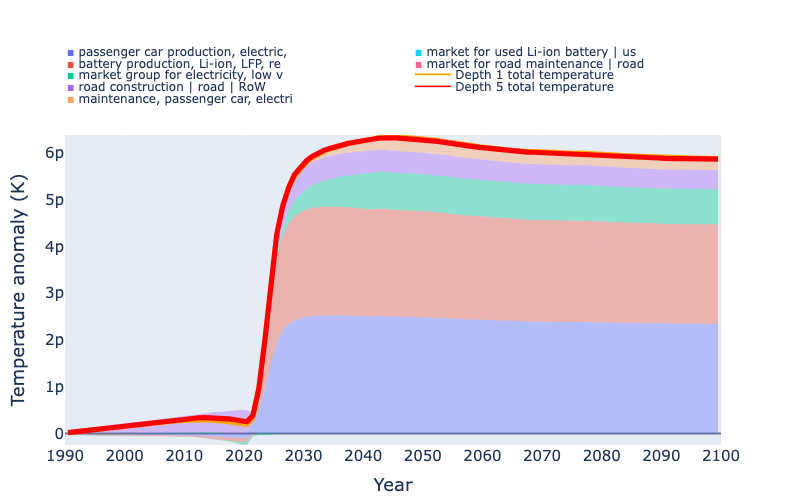

In [23]:
def find_output_figures(
    *,
    suffix: str,
    activity_contains: str | None = None,
    method_contains: str | None = None,
    output_dir: Path = OUTPUT_DIR,
) -> list[Path]:
    figures = sorted(output_dir.rglob(f"*.{suffix}"))
    if activity_contains:
        figures = [
            path for path in figures
            if activity_contains.lower() in str(path.parent).lower()
        ]
    if method_contains:
        figures = [
            path for path in figures
            if method_contains.lower() in path.name.lower()
        ]
    return figures


png_figures = find_output_figures(suffix="png")
html_figures = find_output_figures(suffix="html") if WRITE_HTML else []
print("PNG figures:", len(png_figures))
for path in png_figures[:12]:
    print(path)
if WRITE_HTML:
    print("HTML figures:", len(html_figures))

figures_in_memory = globals().get("figures", [])
if DISPLAY_FIRST_FIGURE and figures_in_memory:
    display(figures_in_memory[0][2])
elif png_figures:
    display(Image(filename=str(png_figures[0])))
elif html_figures:
    display(HTML(f'<a href="{html_figures[0]}">{html_figures[0]}</a>'))


## Notes for Variations

- Change `CASE_KEYS` to run any subset of the four foreground case studies.
- Change `METHOD_MODE` to `ef31_headline` to run the shortlisted EF v3.1 indicators.
- Adjust `PLOT_WINDOW_YEARS_BEFORE` and `PLOT_WINDOW_YEARS_AFTER` if impacts outside the reference-year window should remain visible.
- The notebook now writes high-resolution PNG files by default. Set `WRITE_HTML = True` only if interactive HTML exports are also needed.